# setM Plot Interpretation Guide

This notebook is a reading guide for the setM basin/behavior/phylogeny analysis outputs. It does not rerun the full analysis. Instead, it loads the saved CSVs and PNGs, displays the key figures, and annotates what each plot means.

The central object is a **basin-relative syllable enrichment vector**:

\[
\mathrm{enrichment}_{species, arm, syllable} = \log_2\left(\frac{p(syllable \mid species, arm)}{p(syllable \mid species)}\right)
\]

So the plots are about **which MoSeq syllables are over- or under-represented inside each slow-mode basin**, after normalizing by that species' overall syllable usage. They are not raw syllable frequencies.


In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

OUT_DIR = Path('../outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo').resolve()
BEHAVIOR_DIR = OUT_DIR / 'behavior_enrichment_visualizations'
CLASSIFIER_DIR = OUT_DIR / 'species_chi_trajectory_classifier'
DIRECTION_DIR = OUT_DIR / 'direction_1_interpretation'

species_order = [
    'Mus_caroli',
    'Mus_musculus',
    'Mus_spretus',
    'Peromyscus_polionotus',
    'Peromyscus_californicus',
    'Peromyscus_maniculatus',
    'Peromyscus_gossypinus',
    'Peromyscus_leucopus',
]

def show_png(path, width=None):
    path = Path(path)
    if not path.exists():
        display(Markdown(f'**Missing file:** `{path}`'))
        return
    display(Image(filename=str(path), width=width))

def read_square_csv(path):
    df = pd.read_csv(path, index_col=0)
    return df.loc[df.index.intersection(species_order), df.columns.intersection(species_order)]

def plot_distance_matrix(distance_df, title, cmap='magma_r'):
    fig, ax = plt.subplots(figsize=(6.4, 5.5), constrained_layout=True)
    im = ax.imshow(distance_df.to_numpy(dtype=float), cmap=cmap)
    ax.set_xticks(range(distance_df.shape[1]))
    ax.set_xticklabels([s.replace('_', ' ') for s in distance_df.columns], rotation=45, ha='right')
    ax.set_yticks(range(distance_df.shape[0]))
    ax.set_yticklabels([s.replace('_', ' ') for s in distance_df.index])
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax, shrink=0.82)
    cbar.set_label('distance')
    return fig, ax

print('OUT_DIR:', OUT_DIR)


OUT_DIR: /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/setM_basin_syllable_matching_phylo


## 1. What The Vectors Are

Each species-arm row is a **50-dimensional vector**, one value per MoSeq syllable. With four setM basins per species, each species contributes a **4 x 50 enrichment matrix**.

Important interpretation points:

- positive values: the syllable is enriched in that basin relative to that species' own baseline behavior
- negative values: the syllable is depleted in that basin relative to that species' own baseline behavior
- zero-ish values: the basin uses that syllable about as often as the species does overall
- these vectors compare **behavioral composition of basins**, not the geometry of UMAPs and not raw occupancy

The basin matching plots use these vectors to align arms across species, typically by minimizing correlation distance between arm-level enrichment profiles.


In [3]:
profile = pd.read_csv(OUT_DIR / 'setM_basin_relative_enrichment_profile_table.csv')
label_df = pd.read_csv(OUT_DIR / 'setM_moseq_syllable_labels.csv')

enrichment_cols = [c for c in profile.columns if c.startswith('syllable_')]
summary = pd.DataFrame({
    'quantity': ['rows', 'species', 'arms per species', 'syllables / vector length'],
    'value': [len(profile), profile['species'].nunique(), profile.groupby('species')['arm'].nunique().mode()[0], len(enrichment_cols)],
})
display(summary)
display(profile[['species', 'arm'] + enrichment_cols[:6]].head())
display(label_df.head(12))


,quantity,value
0,rows,32
1,species,8
2,arms per species,4
3,syllables / vector length,50


,species,arm,syllable_0,syllable_1,syllable_2,syllable_3,syllable_4,syllable_5
0,Mus_caroli,0,-0.299940,-0.053669,-0.194103,-0.269616,-0.274639,0.287650
1,Mus_caroli,1,0.323192,0.113887,0.278274,0.270856,0.250348,-0.291601
2,Mus_caroli,2,-0.039258,-0.070159,-0.174278,0.037634,0.079659,-0.188761
3,Mus_caroli,3,-0.009649,-0.115812,0.087976,-0.085298,-0.041044,-0.316427
4,Mus_musculus,0,0.104995,0.108049,0.067283,0.127663,0.119020,0.164158


,moseq_cluster,moseq_label,moseq_syllable_name,moseq_category,syllable_label
0,0,0: head_low,NaN,NaN,0: head_low
1,1,1: head_down,NaN,NaN,1: head_down
2,2,2: sniff_floor,NaN,NaN,2: sniff_floor
3,3,3: step_to_stop,NaN,NaN,3: step_to_stop
4,4,4: turn_left,NaN,NaN,4: turn_left
5,5,5: enter_rear,NaN,NaN,5: enter_rear
6,6,6: turn_right,NaN,NaN,6: turn_right
7,7,7: extend_rear,NaN,NaN,7: extend_rear
8,8,8: extend_rear_2,NaN,NaN,8: extend_rear_2
9,9,9: still,NaN,NaN,9: still


## 2. Species Distance Matrices And Dendrograms

These matrices summarize how similar species are after matching their basins. For the matched enrichment correlation distance, low values mean two species have similar basin-specific syllable enrichment profiles after optimal arm matching.

How to read this:

- the diagonal is zero by construction
- darker/lower off-diagonal entries indicate behaviorally similar basin enrichment structure
- hierarchical clustering asks whether those distances recover taxonomic structure
- a phylogenetic signal is stronger if close relatives cluster without needing arbitrary plotting choices

Caution: this is a behavioral representation, not a phylogeny estimate. It can contain ecological, dataset, sampling, and model effects in addition to evolutionary signal.


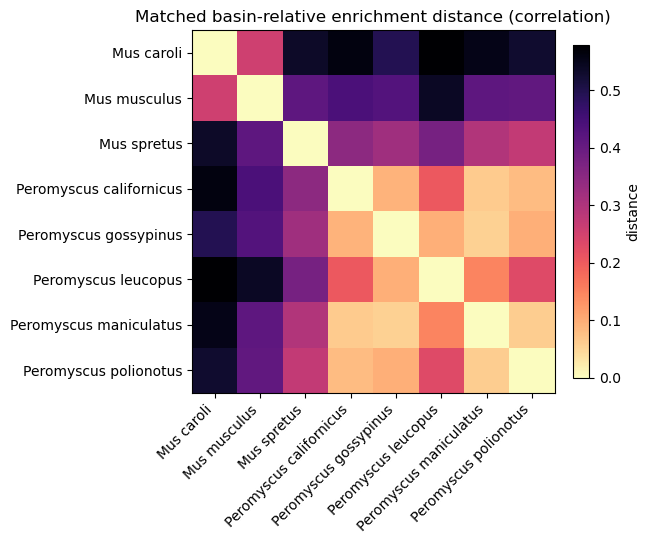

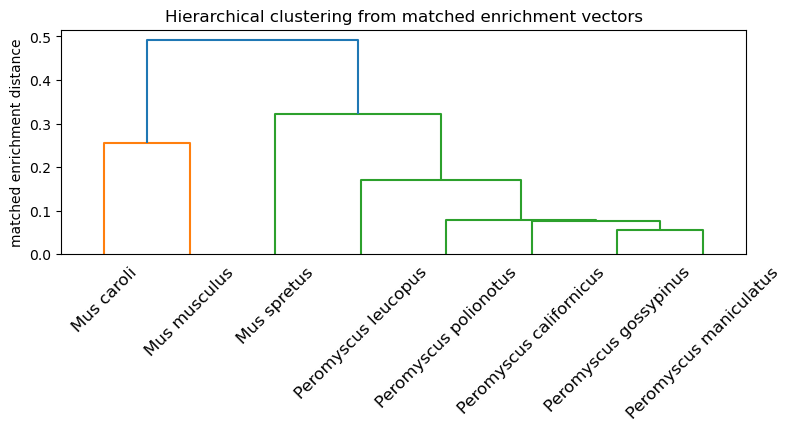

In [4]:
corr_dist = read_square_csv(OUT_DIR / 'setM_matched_basin_enrichment_species_correlation_distance.csv')
plot_distance_matrix(corr_dist, 'Matched basin-relative enrichment distance (correlation)')
plt.show()

Z = linkage(squareform(corr_dist.to_numpy(dtype=float), checks=False), method='average')
fig, ax = plt.subplots(figsize=(7.8, 4.2), constrained_layout=True)
dendrogram(Z, labels=[s.replace('_', ' ') for s in corr_dist.index], leaf_rotation=45, ax=ax)
ax.set_ylabel('matched enrichment distance')
ax.set_title('Hierarchical clustering from matched enrichment vectors')
plt.show()


## 3. Distribution Distances: JS And Hellinger

JS and Hellinger distances are useful when treating each arm/syllable profile as a probability-like distribution rather than a signed enrichment profile. In this analysis they are safest when applied to comparable, species-aligned representations.

How to read this:

- JS distance emphasizes differences between full distributions and is bounded
- Hellinger distance is also distributional and often behaves smoothly for sparse probabilities
- if these agree with the correlation-enrichment matrix, the signal is less tied to one distance choice
- if they disagree, inspect whether the difference is driven by a few high-frequency syllables or broad profile shifts


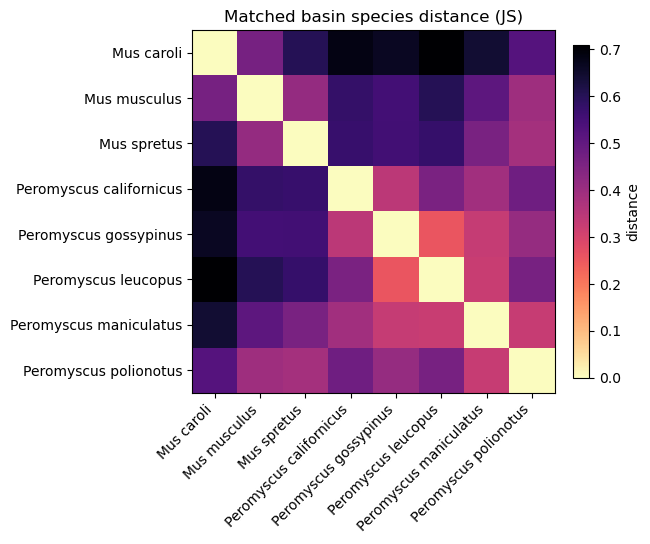

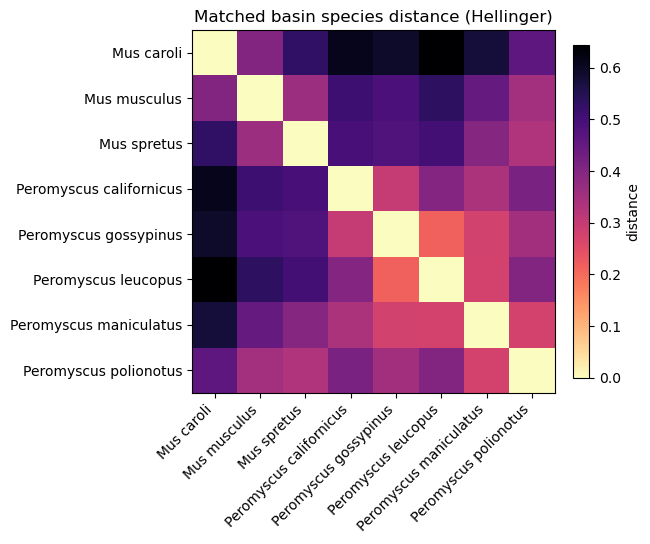

In [5]:
for filename, title in [
    ('setM_matched_basin_species_js_distance.csv', 'Matched basin species distance (JS)'),
    ('setM_matched_basin_species_hellinger_distance.csv', 'Matched basin species distance (Hellinger)'),
]:
    path = OUT_DIR / filename
    if path.exists():
        df = read_square_csv(path)
        plot_distance_matrix(df, title)
        plt.show()
    else:
        display(Markdown(f'Missing `{filename}`'))


## 4. Matched-Arm Heatmaps

This plot shows species-by-syllable enrichment after arms have been aligned to a reference species. It is the best first-pass view for asking, "Which behaviors define each matched basin, and are those definitions conserved across species?"

How to read this:

- each panel/arm is a matched basin
- rows are species; columns are MoSeq syllables
- red/positive cells are enriched in that species' matched basin
- blue/negative cells are depleted
- conserved vertical bands suggest shared basin behavioral identity
- species-specific stripes suggest divergence in that basin's behavioral composition


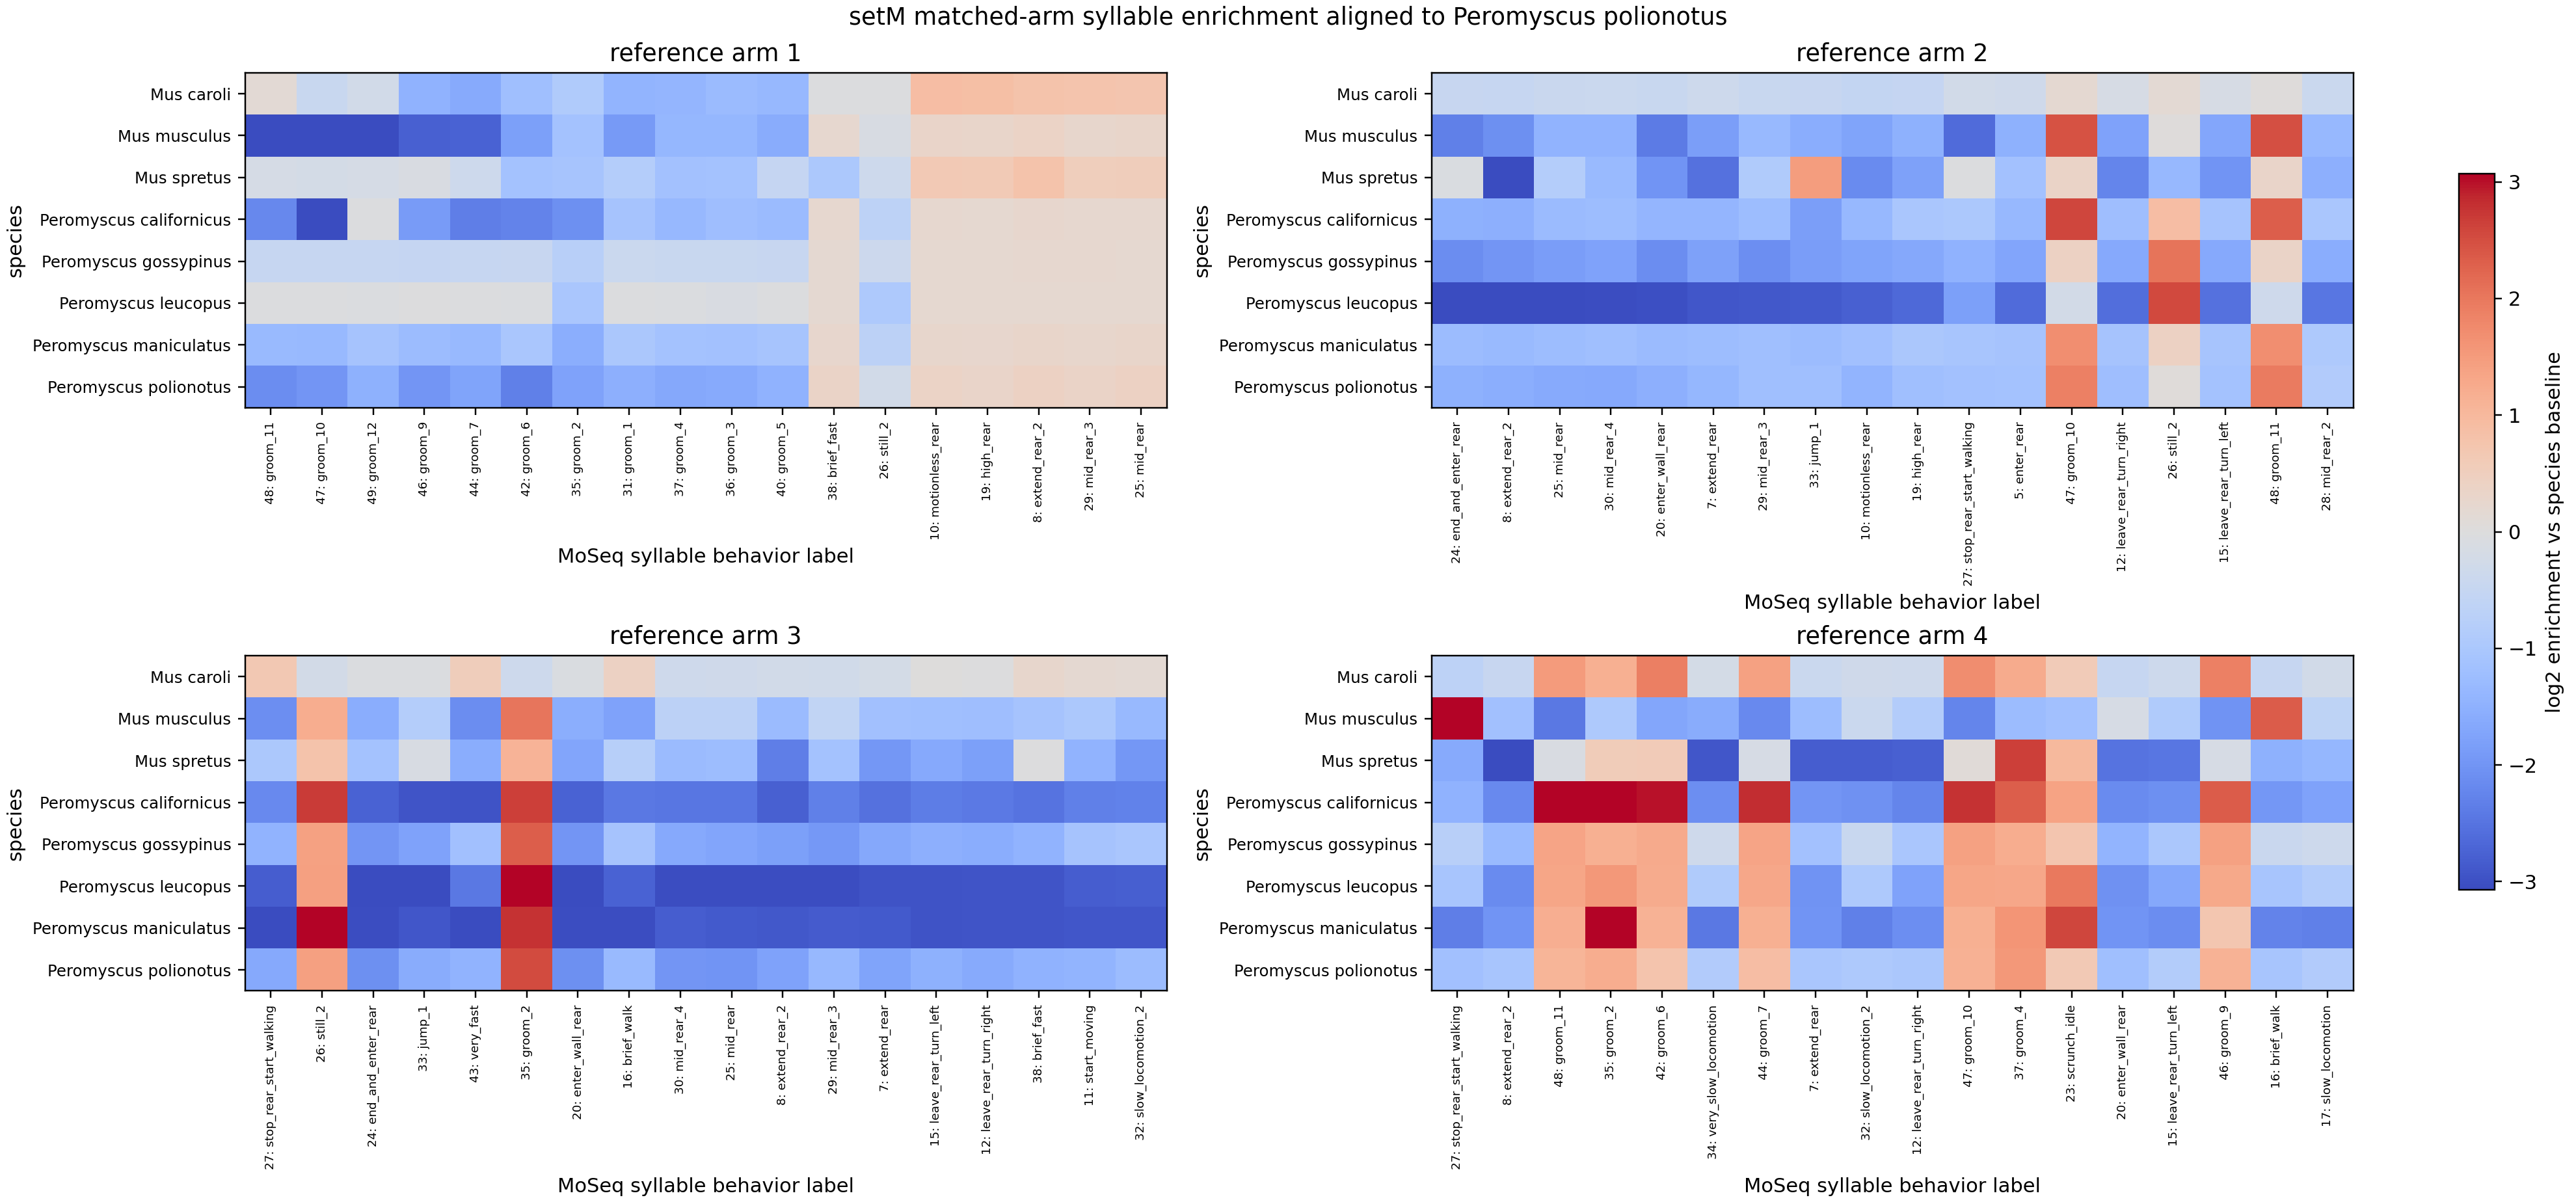

In [6]:
show_png(BEHAVIOR_DIR / 'setM_matched_arm_species_by_syllable_enrichment_heatmaps.png', width=1200)


## 5. Top Driver Syllable Dot Plot

The dot plot pulls out syllables that contribute most strongly to interspecies differences. It is cleaner than the full heatmap when you want to name candidate behaviors.

How to read this:

- each dot is a species-arm-syllable enrichment value
- color encodes enrichment sign/magnitude
- size usually tracks absolute magnitude or driver strength, depending on the plotting cell
- repeated high-magnitude differences for the same syllable point to interpretable behavioral axes

Good follow-up: open the underlying CSV and sort by absolute driver score or by a specific syllable label.


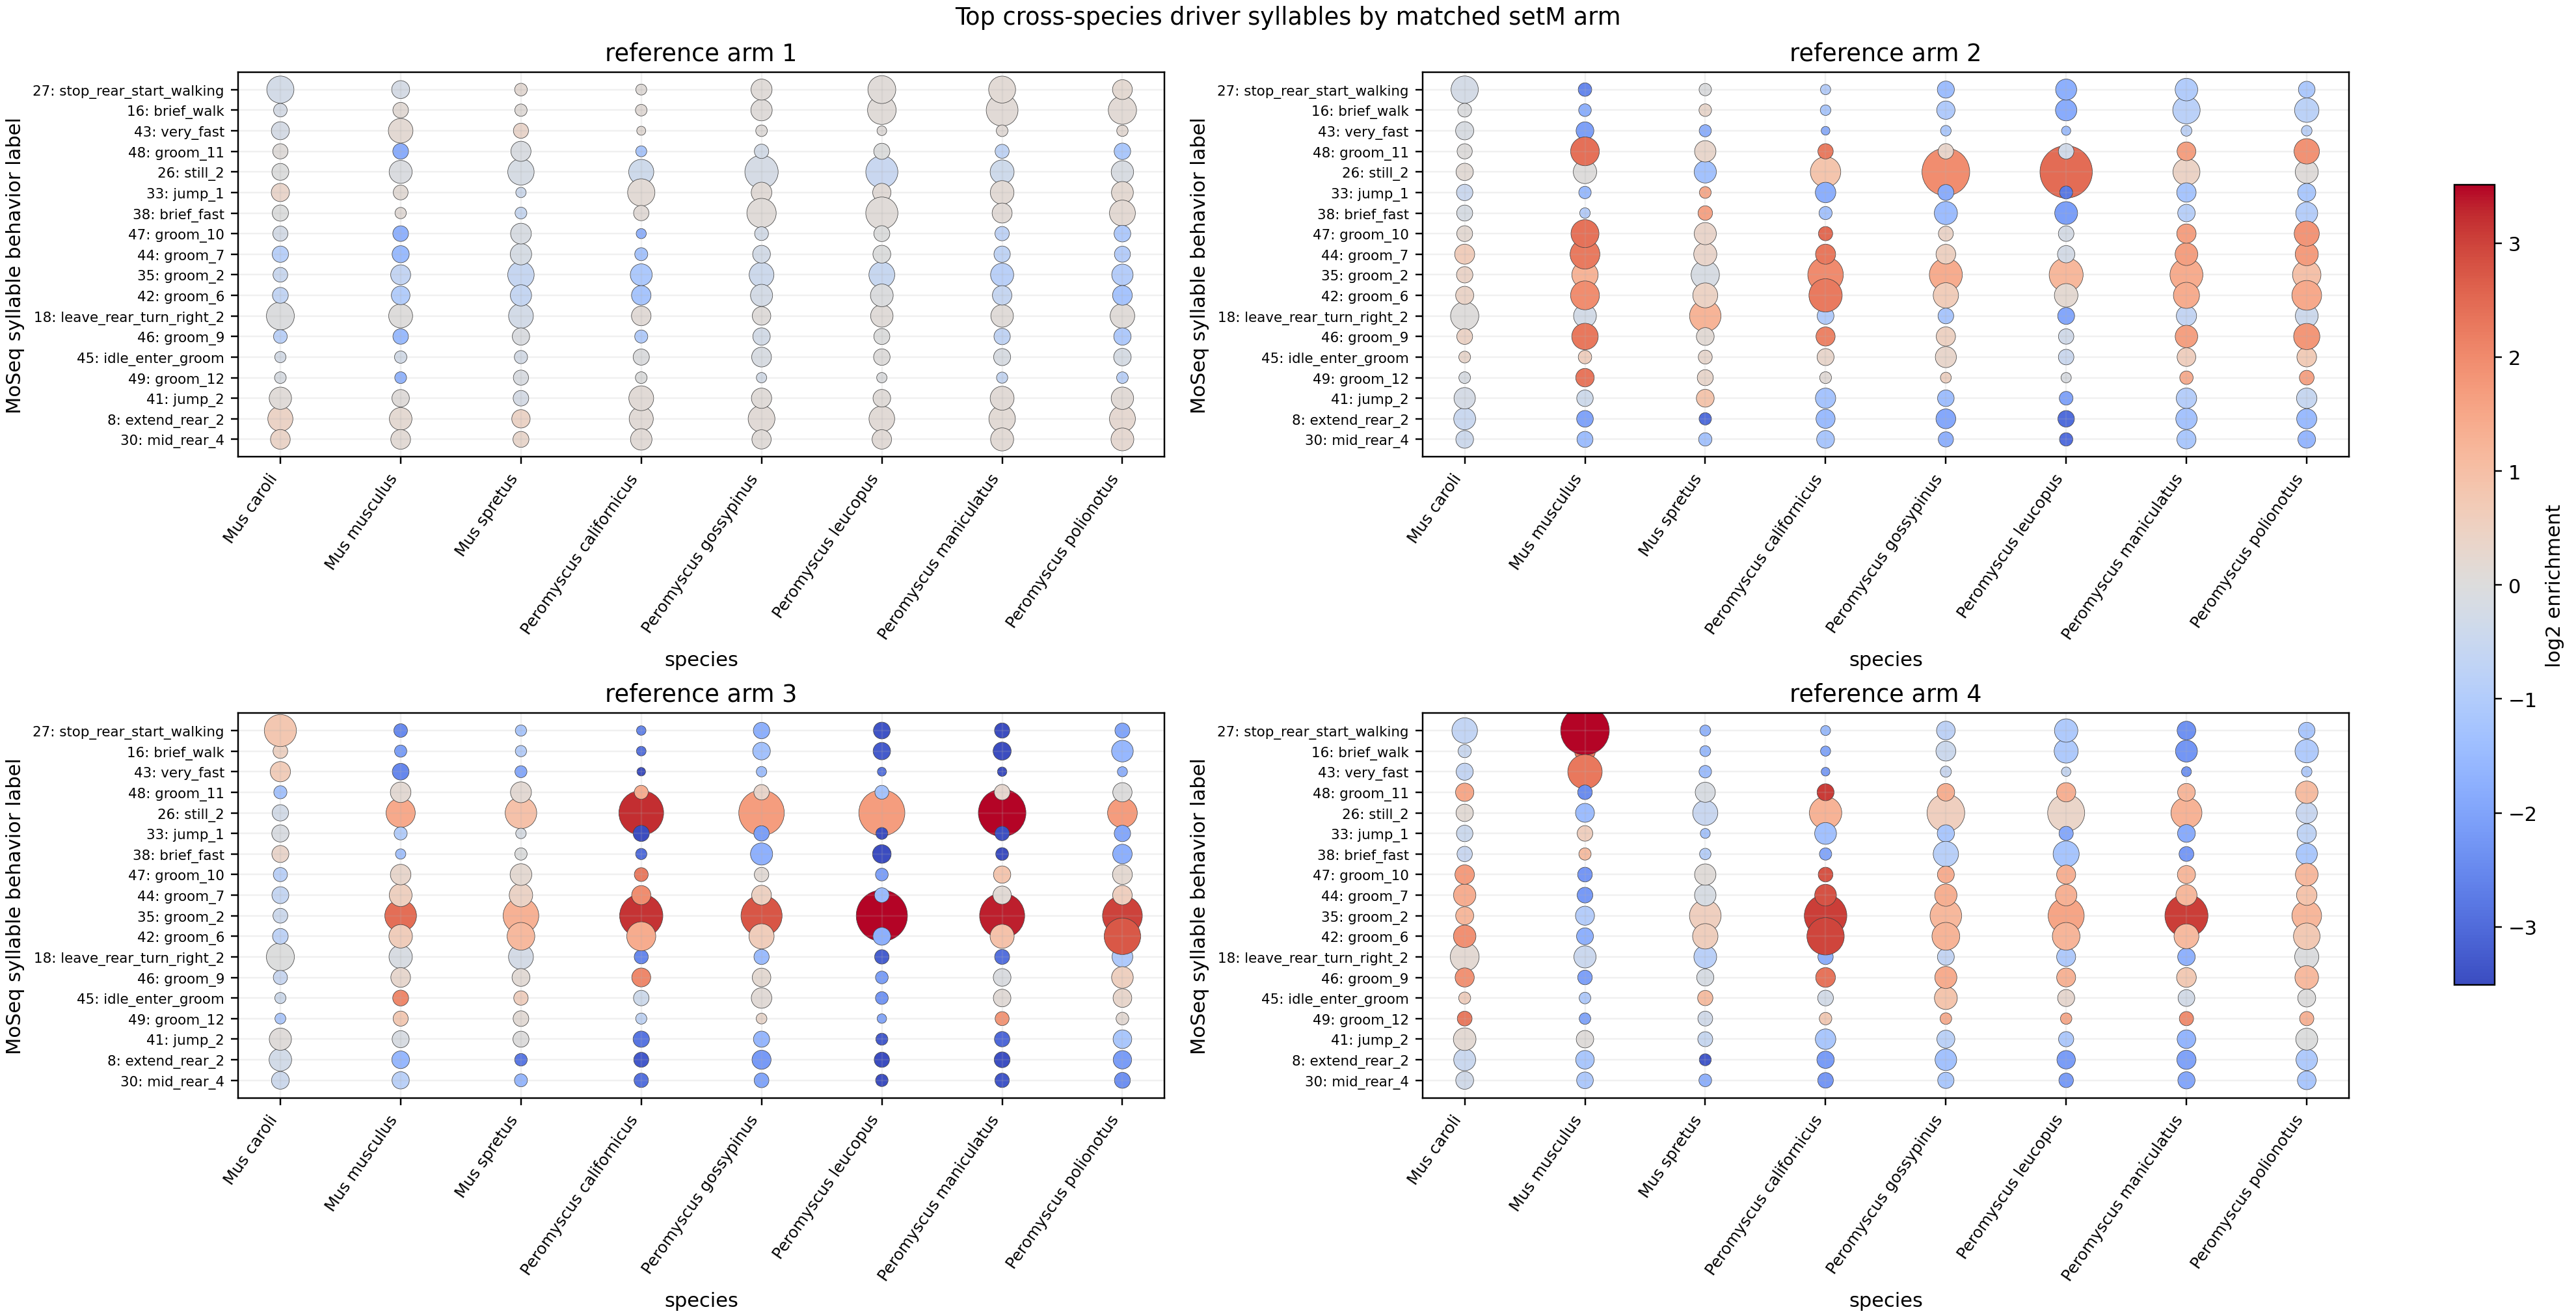

,species,genus,reference_species,reference_arm,matched_species_arm,syllable,syllable_label,moseq_syllable_name,moseq_category,log2_enrichment,arm_syllable_probability,species_plot,syllable_plot
0,Mus_caroli,Mus,Peromyscus_polionotus,0,0,8,8: extend_rear_2,NaN,NaN,0.418461,0.024661,Mus_caroli,8
1,Mus_caroli,Mus,Peromyscus_polionotus,0,0,16,16: brief_walk,NaN,NaN,-0.198326,0.000999,Mus_caroli,16
2,Mus_caroli,Mus,Peromyscus_polionotus,0,0,18,18: leave_rear_turn_right_2,NaN,NaN,-0.038775,0.039708,Mus_caroli,18
3,Mus_caroli,Mus,Peromyscus_polionotus,0,0,26,26: still_2,NaN,NaN,-0.023274,0.003666,Mus_caroli,26
4,Mus_caroli,Mus,Peromyscus_polionotus,0,0,27,27: stop_rear_start_walking,NaN,NaN,-0.262862,0.034970,Mus_caroli,27
5,Mus_caroli,Mus,Peromyscus_polionotus,0,0,30,30: mid_rear_4,NaN,NaN,0.394268,0.008011,Mus_caroli,30
6,Mus_caroli,Mus,Peromyscus_polionotus,0,0,33,33: jump_1,NaN,NaN,0.343228,0.005334,Mus_caroli,33
7,Mus_caroli,Mus,Peromyscus_polionotus,0,0,35,35: groom_2,NaN,NaN,-0.479390,0.001647,Mus_caroli,35
8,Mus_caroli,Mus,Peromyscus_polionotus,0,0,38,38: brief_fast,NaN,NaN,-0.021198,0.002913,Mus_caroli,38
9,Mus_caroli,Mus,Peromyscus_polionotus,0,0,41,41: jump_2,NaN,NaN,0.096998,0.014375,Mus_caroli,41


In [7]:
show_png(BEHAVIOR_DIR / 'setM_matched_arm_top_driver_syllable_dotplot.png', width=1100)

driver_values = pd.read_csv(BEHAVIOR_DIR / 'setM_matched_arm_top_driver_syllable_dotplot_values.csv')
display(driver_values.head(12))


## 6. Genus Contrast Plot

This plot compresses species-level variation into a Mus-vs-Peromyscus contrast for the most shifted syllables. It is useful as a summary, but it is less granular than the species-level heatmap.

How to read this:

- positive contrast means higher enrichment in the plotted positive side's genus, as defined by the plotting table
- negative contrast means the opposite genus is higher
- use it to generate hypotheses, then verify with species-level rows
- be careful if one species is an outlier within a genus; genus summaries can hide that


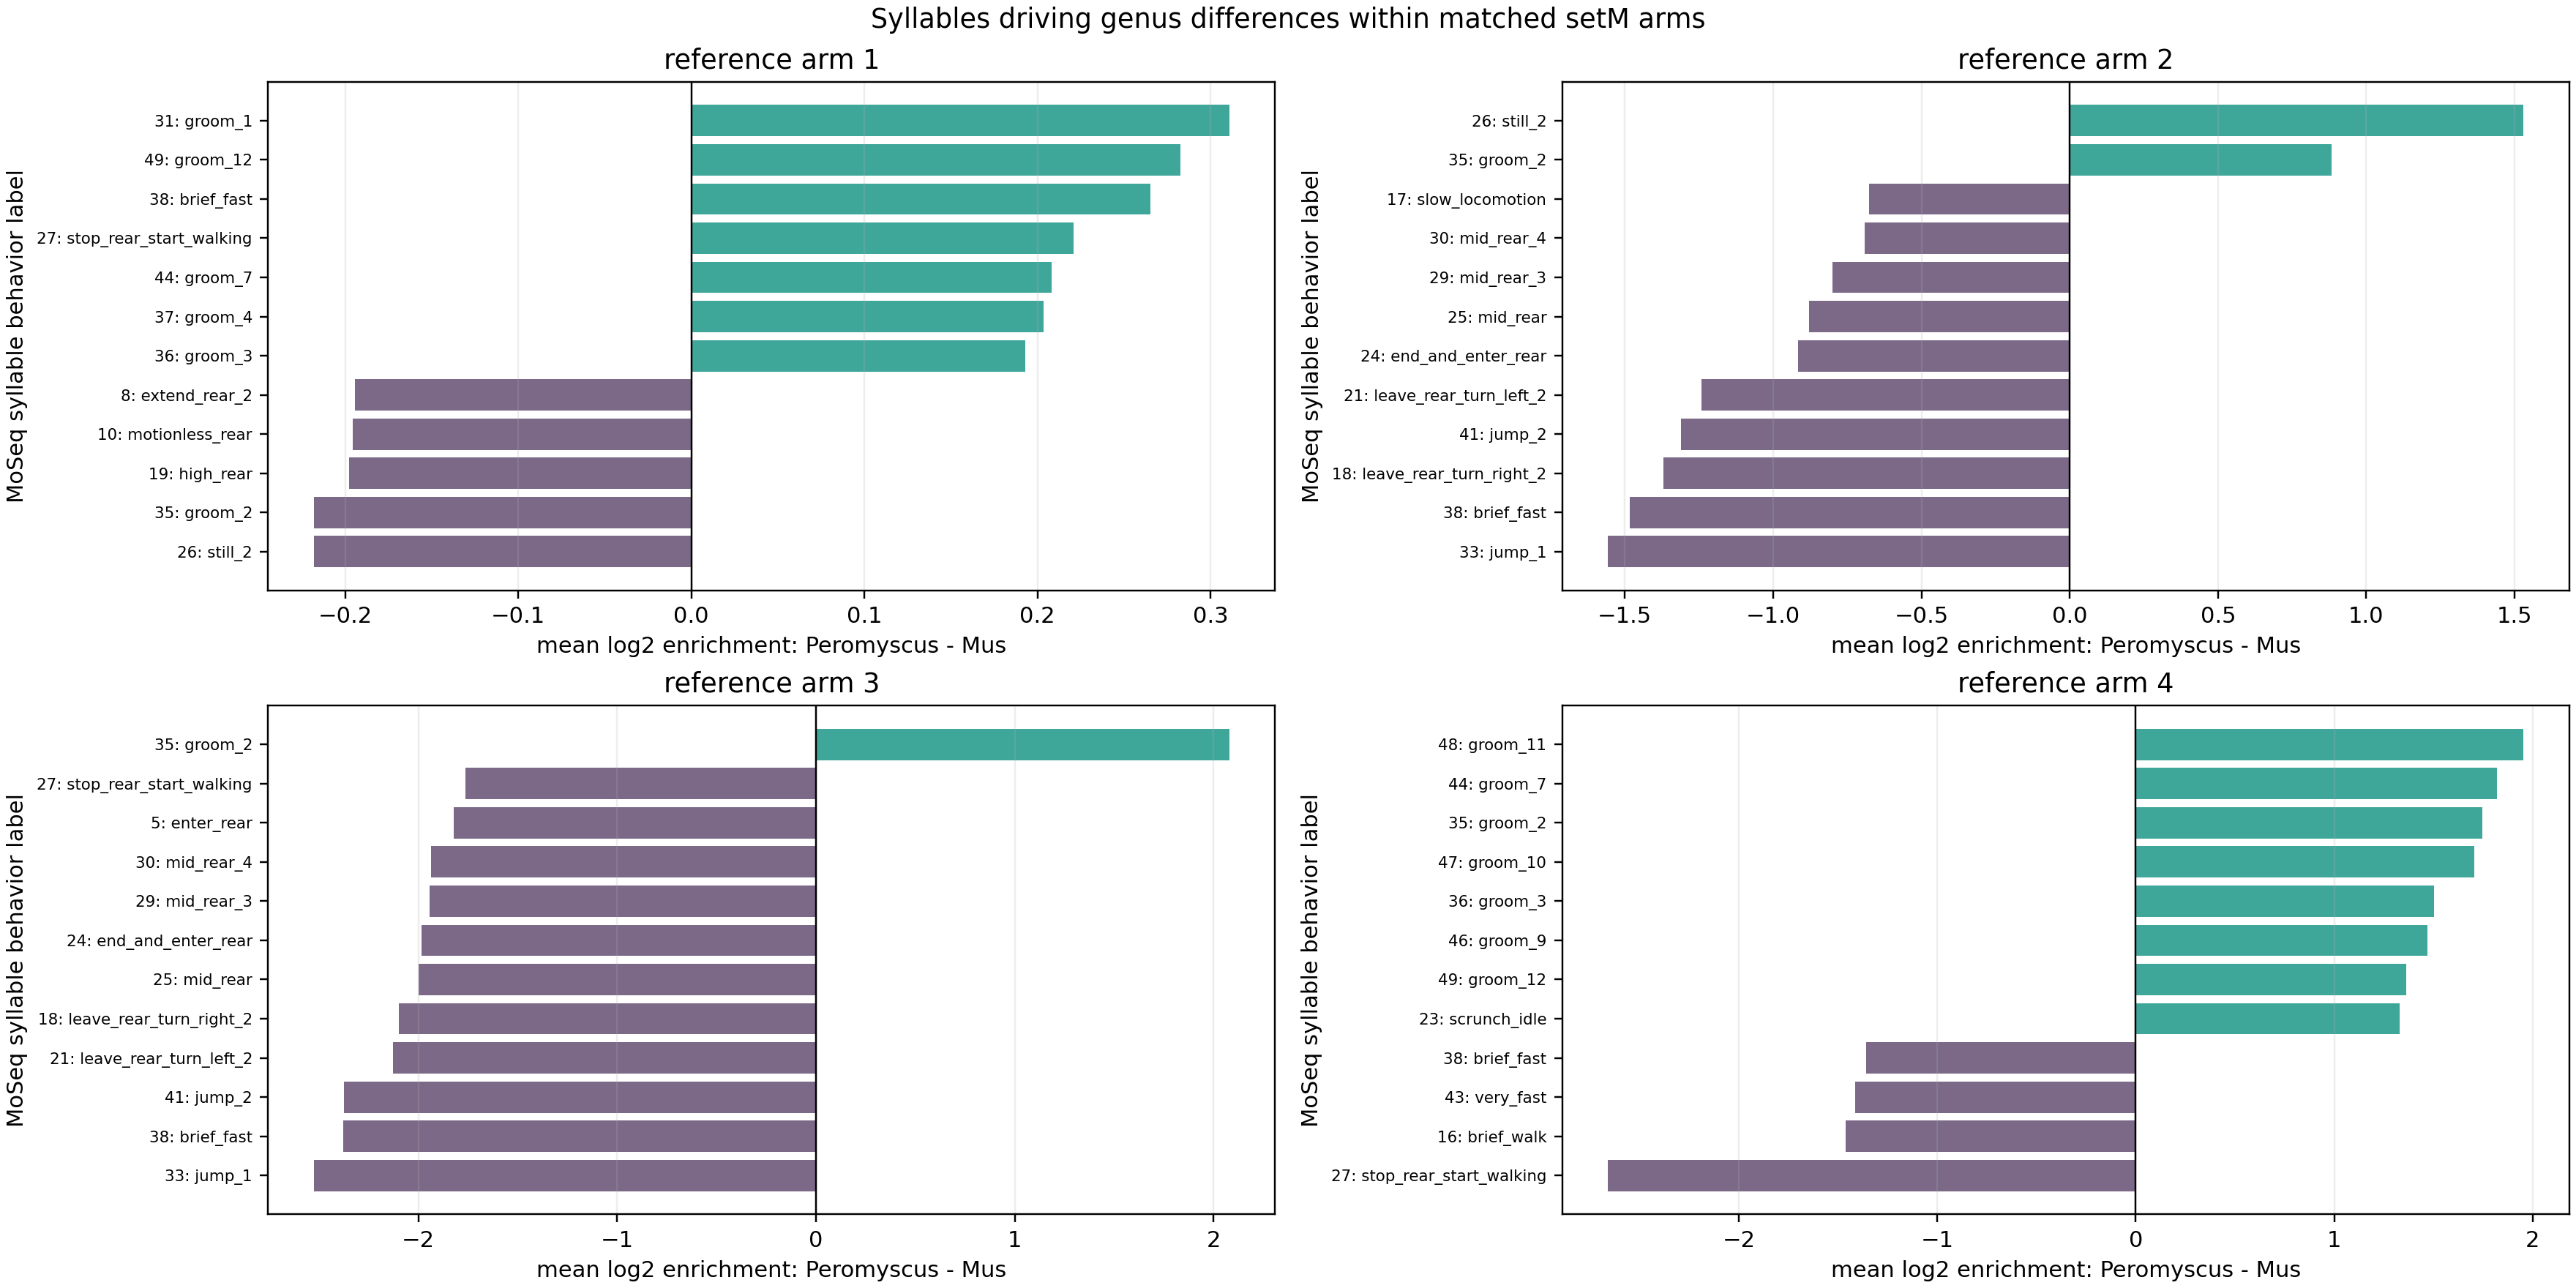

,reference_arm,syllable,Mus,Peromyscus,Peromyscus_minus_Mus,syllable_label,moseq_syllable_name,moseq_category
0,0,0,0.041221,0.036613,-0.004608,0: head_low,NaN,NaN
1,0,1,0.131008,0.071610,-0.059398,1: head_down,NaN,NaN
2,0,2,0.043448,0.005691,-0.037757,2: sniff_floor,NaN,NaN
3,0,3,0.032012,0.065603,0.033591,3: step_to_stop,NaN,NaN
4,0,4,0.019941,0.063226,0.043286,4: turn_left,NaN,NaN
5,0,5,0.253641,0.135190,-0.118451,5: enter_rear,NaN,NaN
6,0,6,-0.070809,0.062531,0.133340,6: turn_right,NaN,NaN
7,0,7,0.303968,0.144035,-0.159933,7: extend_rear,NaN,NaN
8,0,8,0.344540,0.150256,-0.194285,8: extend_rear_2,NaN,NaN
9,0,9,0.110462,0.044667,-0.065795,9: still,NaN,NaN


In [8]:
show_png(BEHAVIOR_DIR / 'setM_matched_arm_genus_contrast_top_syllables.png', width=1150)

genus_contrast = pd.read_csv(BEHAVIOR_DIR / 'setM_matched_arm_genus_enrichment_contrast.csv')
display(genus_contrast.head(12))


## 7. Fluctuation-Divergence Alignment

This analysis compares directions of within-species variability to directions of between-species divergence in aligned setM chi space.

Interpretation:

- a high within-species variance direction is a behavioral mode that animals frequently explore within species
- high between-species divergence along the same direction means species means differ along that same mode
- if within and between variation align, evolution/species differences may be reusing an axis already present as individual/within-species fluctuation

In the current run, Direction 1 dominates within-species variance and also has the largest species score range, so the guide below focuses on Direction 1.


,direction,within_variance,between_species_divergence,ratio_between_to_within,species_score_range
0,1,5.015763e-02,3.764279e-02,7.504898e-01,5.897619e-01
1,2,7.294073e-03,2.562008e-03,3.512452e-01,1.380274e-01
2,3,2.442466e-03,1.188073e-03,4.864236e-01,1.023716e-01
3,4,2.453007e-18,-3.286488e-19,-3.286488e-07,2.764455e-14


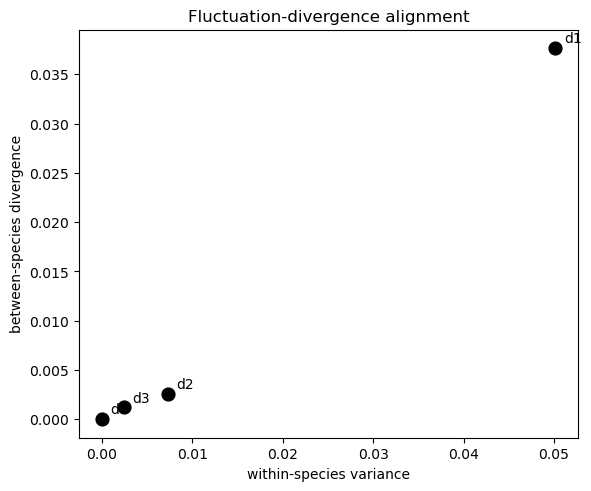

In [23]:
fluct = pd.read_csv(OUT_DIR / 'setM_fluctuation_divergence_by_within_species_direction.csv')
display(fluct)

fig, ax = plt.subplots(figsize=(5.8, 4.8), constrained_layout=True)
ax.scatter(fluct['within_variance'], fluct['between_species_divergence'], s=85, color='black')
for _, row in fluct.iterrows():
    ax.annotate(f"d{int(row['direction'])}", (row['within_variance'], row['between_species_divergence']), textcoords='offset points', xytext=(6, 4))
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('within-species variance')
ax.set_ylabel('between-species divergence')
ax.set_title('Fluctuation-divergence alignment')
plt.show()



## 8. Fluctuation-Dissipation Alignment Null Test

This is the formal version of the "do the animals' wiggles predict how species diverged?" plot. The observed scatter asks whether retained within-species fluctuation directions with high variance also carry high between-species divergence.

The rotation null makes the test sharper: it keeps the within-species covariance spectrum and the between-species covariance spectrum fixed, but randomizes their relative orientation. If the observed correlation or top-axis divergence share is larger than most rotations, then between-species divergence is specifically aligned with the animals' within-species fluctuation geometry.

Good result pattern:

- high observed log correlation between within variance and between divergence
- most between-species divergence concentrated on the top within-species fluctuation axis
- low rotation-null p-values

Caution: with only three retained directions, p-values should be read as a geometric diagnostic rather than a stand-alone proof. The value is that it directly tests the lines-of-least-resistance hypothesis in the aligned slow-mode coordinates.


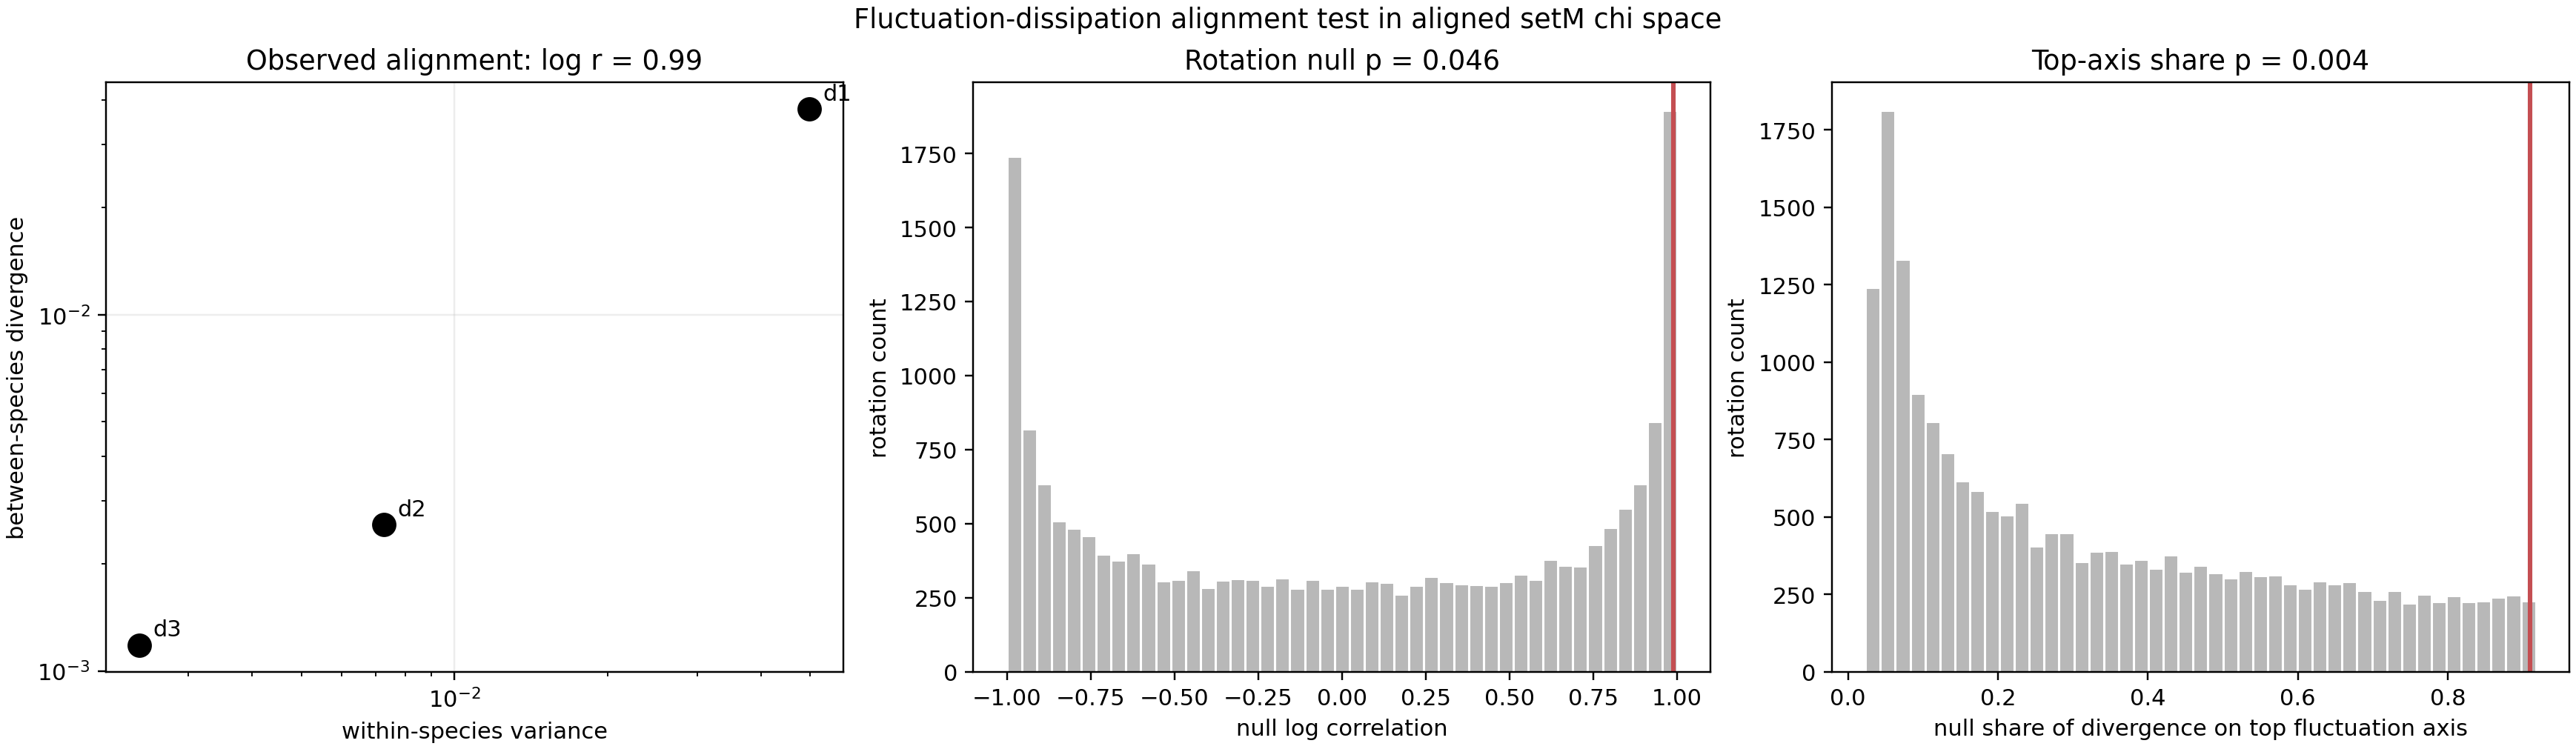

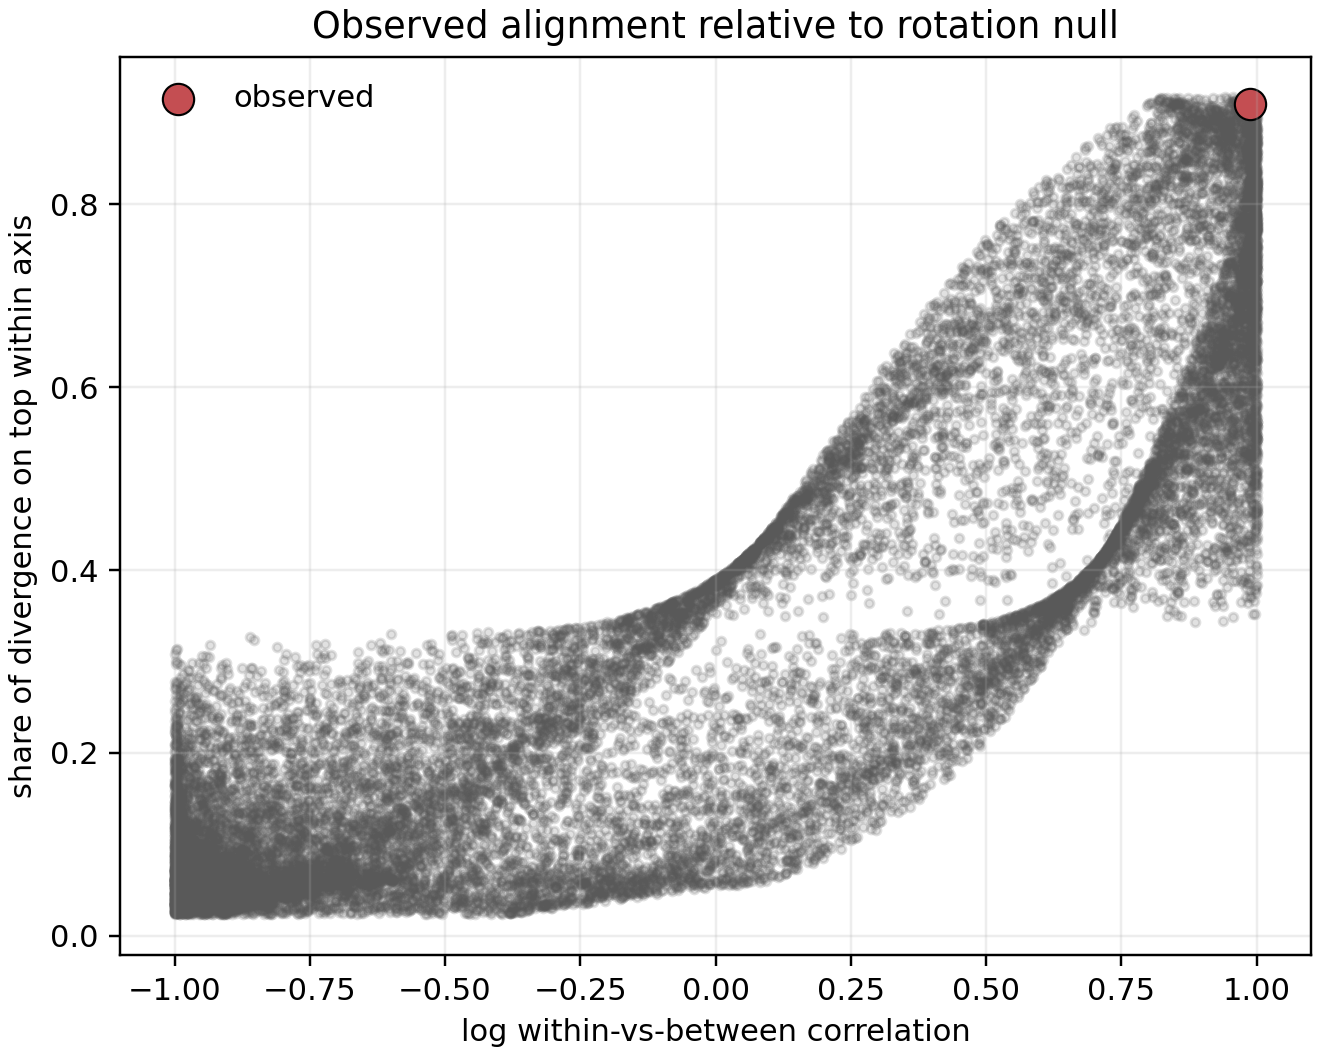

,direction,within_variance,between_species_divergence,log10_within_variance,log10_between_species_divergence,between_divergence_share
0,1,0.049860,0.037826,-1.302247,-1.422205,0.909721
1,2,0.007259,0.002572,-2.139153,-2.589810,0.061845
2,3,0.002401,0.001182,-2.619680,-2.927269,0.028434


,n_retained_directions,n_rotation_nulls,observed_log_pearson,rotation_null_p_log_pearson_upper_tail,observed_log_slope,rotation_null_p_log_slope_upper_tail,observed_top_within_direction_between_divergence_share,rotation_null_p_top_share_upper_tail
0,3,20000,0.988262,0.046448,1.170685,0.00175,0.909721,0.0041


In [18]:

FLUCT_DISS_DIR = OUT_DIR / 'fluctuation_dissipation_alignment_test'

show_png(FLUCT_DISS_DIR / 'setM_fluctuation_dissipation_alignment_rotation_null.png', width=1200)
show_png(FLUCT_DISS_DIR / 'setM_fluctuation_dissipation_joint_null_position.png', width=760)

fluct_diss_obs = pd.read_csv(FLUCT_DISS_DIR / 'setM_fluctuation_dissipation_observed_directions.csv')
fluct_diss_summary = pd.read_csv(FLUCT_DISS_DIR / 'setM_fluctuation_dissipation_alignment_summary.csv')

display(fluct_diss_obs)
display(fluct_diss_summary)


## 9. Direction 1 Interpretation

This is the cleaner replacement for a dense cloud plot. It breaks Direction 1 into three linked views:

- where each species sits along the axis
- which aligned arms define the axis
- which MoSeq syllables are enriched at the positive and negative poles

In the current output, Direction 1 is primarily a tradeoff between **reference arm 1** and the other aligned arms. The positive behavior pole is grooming-heavy; the negative pole is rear/extend-rear-heavy.


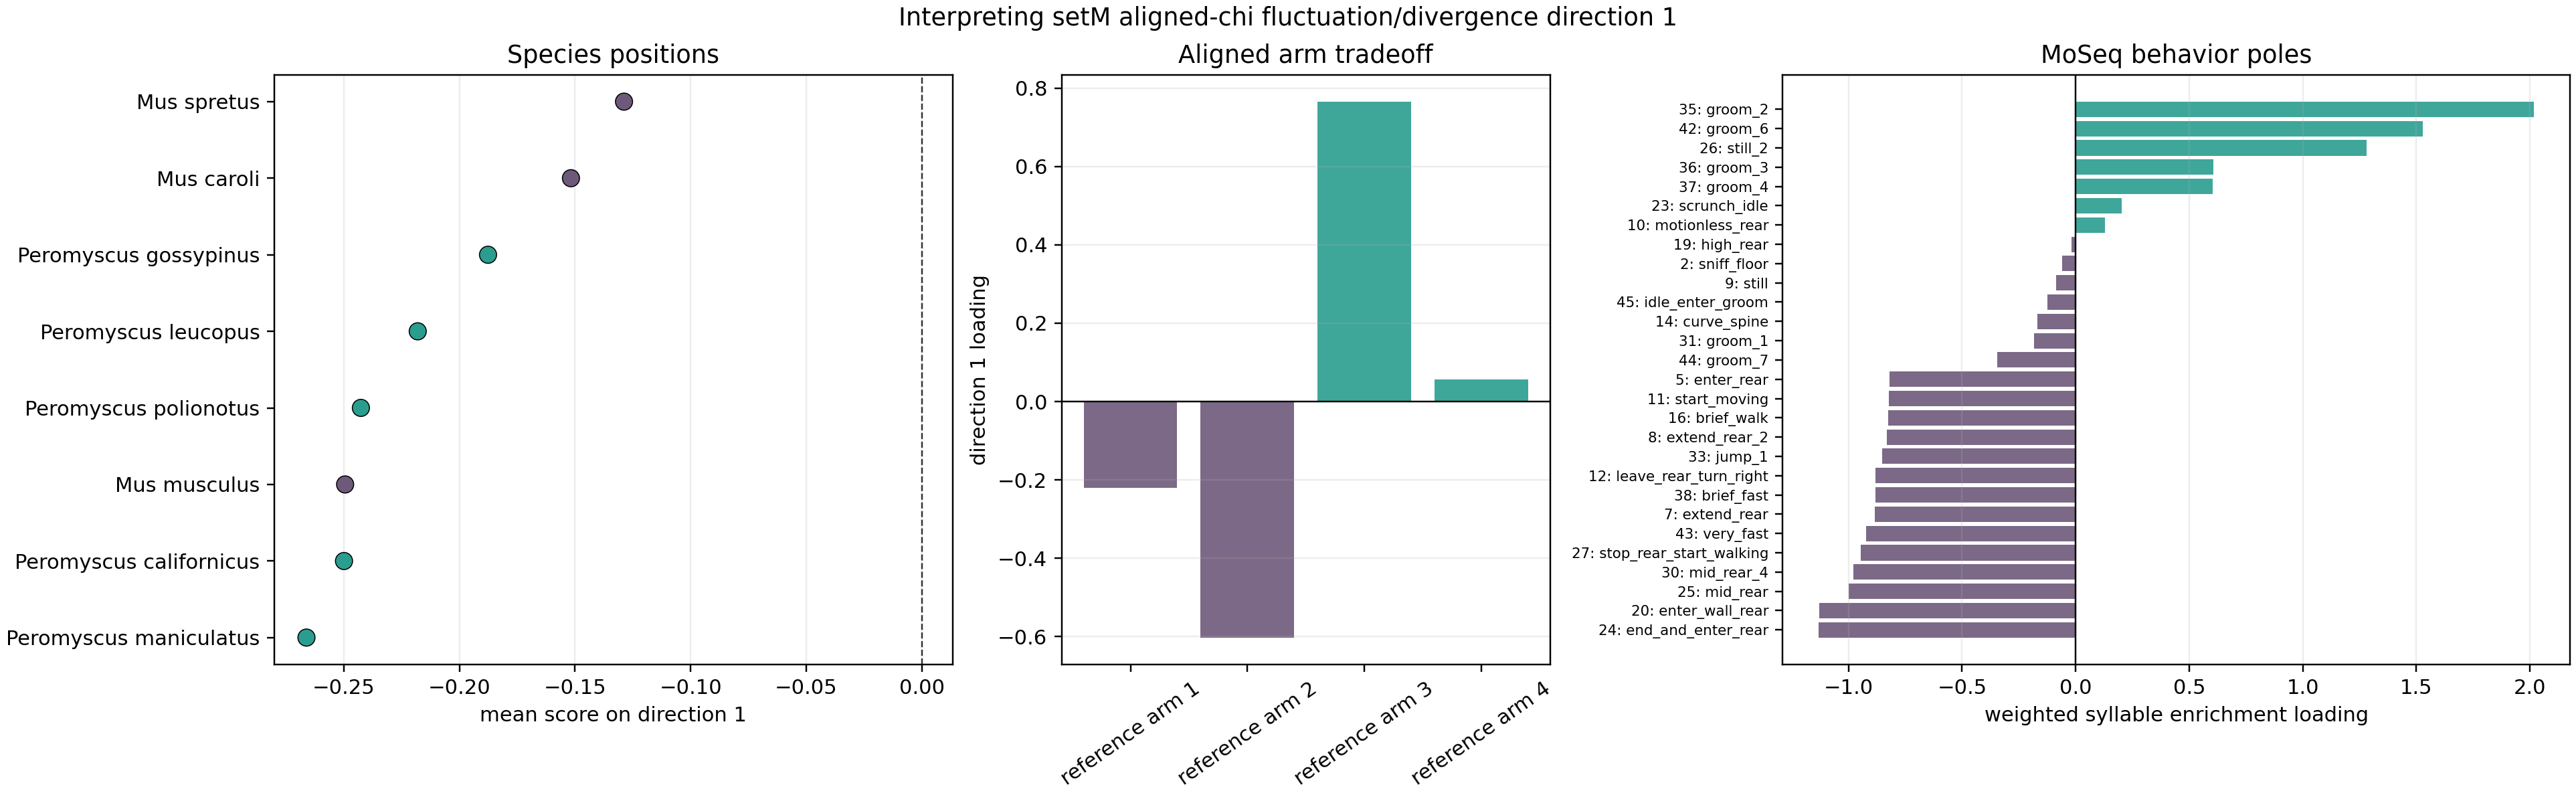

,species,genus,direction_1_score,ci_low,ci_high,frame_score_sd,n_sampled_frames
0,Peromyscus_maniculatus,Peromyscus,-0.266155,-0.266737,-0.265557,0.073527,60000
1,Peromyscus_californicus,Peromyscus,-0.249925,-0.250365,-0.249469,0.062505,60000
2,Mus_musculus,Mus,-0.249442,-0.250118,-0.248666,0.091748,60000
3,Peromyscus_polionotus,Peromyscus,-0.242622,-0.243284,-0.242010,0.081967,60000
4,Peromyscus_leucopus,Peromyscus,-0.218042,-0.218796,-0.217302,0.095247,60000
5,Peromyscus_gossypinus,Peromyscus,-0.187647,-0.188069,-0.187226,0.052724,60000
6,Mus_caroli,Mus,-0.151787,-0.152456,-0.151211,0.075131,60000
7,Mus_spretus,Mus,-0.128840,-0.129852,-0.127805,0.128468,60000


,reference_arm,reference_arm_label,direction_1_loading
0,0,reference arm 1,-0.219884
1,1,reference arm 2,-0.602158
2,2,reference arm 3,0.765408
3,3,reference arm 4,0.056635


,syllable,syllable_label,moseq_syllable_name,moseq_category,direction_1_behavior_loading,abs_loading
49,35,35: groom_2,NaN,NaN,2.018205,2.018205
48,42,42: groom_6,NaN,NaN,1.528282,1.528282
47,26,26: still_2,NaN,NaN,1.279337,1.279337
46,36,36: groom_3,NaN,NaN,0.605162,0.605162
45,37,37: groom_4,NaN,NaN,0.602383,0.602383
44,23,23: scrunch_idle,NaN,NaN,0.201459,0.201459
43,10,10: motionless_rear,NaN,NaN,0.129845,0.129845
42,19,19: high_rear,NaN,NaN,-0.016928,0.016928
41,2,2: sniff_floor,NaN,NaN,-0.060655,0.060655
40,9,9: still,NaN,NaN,-0.085724,0.085724


,syllable,syllable_label,moseq_syllable_name,moseq_category,direction_1_behavior_loading,abs_loading
0,24,24: end_and_enter_rear,NaN,NaN,-1.131813,1.131813
1,20,20: enter_wall_rear,NaN,NaN,-1.128436,1.128436
2,25,25: mid_rear,NaN,NaN,-0.999822,0.999822
3,30,30: mid_rear_4,NaN,NaN,-0.979777,0.979777
4,27,27: stop_rear_start_walking,NaN,NaN,-0.946706,0.946706
5,43,43: very_fast,NaN,NaN,-0.923971,0.923971
6,7,7: extend_rear,NaN,NaN,-0.884651,0.884651
7,38,38: brief_fast,NaN,NaN,-0.882469,0.882469
8,12,12: leave_rear_turn_right,NaN,NaN,-0.880453,0.880453
9,33,33: jump_1,NaN,NaN,-0.852371,0.852371


In [24]:
show_png(DIRECTION_DIR / 'setM_direction_1_species_arm_behavior_summary.png', width=1300)

species_d1 = pd.read_csv(DIRECTION_DIR / 'setM_direction_1_species_scores_with_bootstrap_ci.csv')
arm_d1 = pd.read_csv(DIRECTION_DIR / 'setM_direction_1_reference_arm_loadings.csv')
behavior_d1 = pd.read_csv(DIRECTION_DIR / 'setM_direction_1_behavior_syllable_loadings.csv')

display(species_d1)
display(arm_d1)
display(behavior_d1.sort_values('direction_1_behavior_loading', ascending=False).head(10))
display(behavior_d1.sort_values('direction_1_behavior_loading').head(10))


## 10. Direction 1 Mean vs Within-Species Spread

This plot asks whether species that differ in mean Direction 1 score also differ in how broadly they sample that direction.

How to read this:

- x-axis: species average position along Direction 1
- y-axis: within-species frame-level spread along Direction 1
- a species far right/left has a shifted mean state
- a species high/low on y has broader/narrower use of this axis

This is helpful because phylogenetic signal could appear as a mean shift, a variability shift, or both.


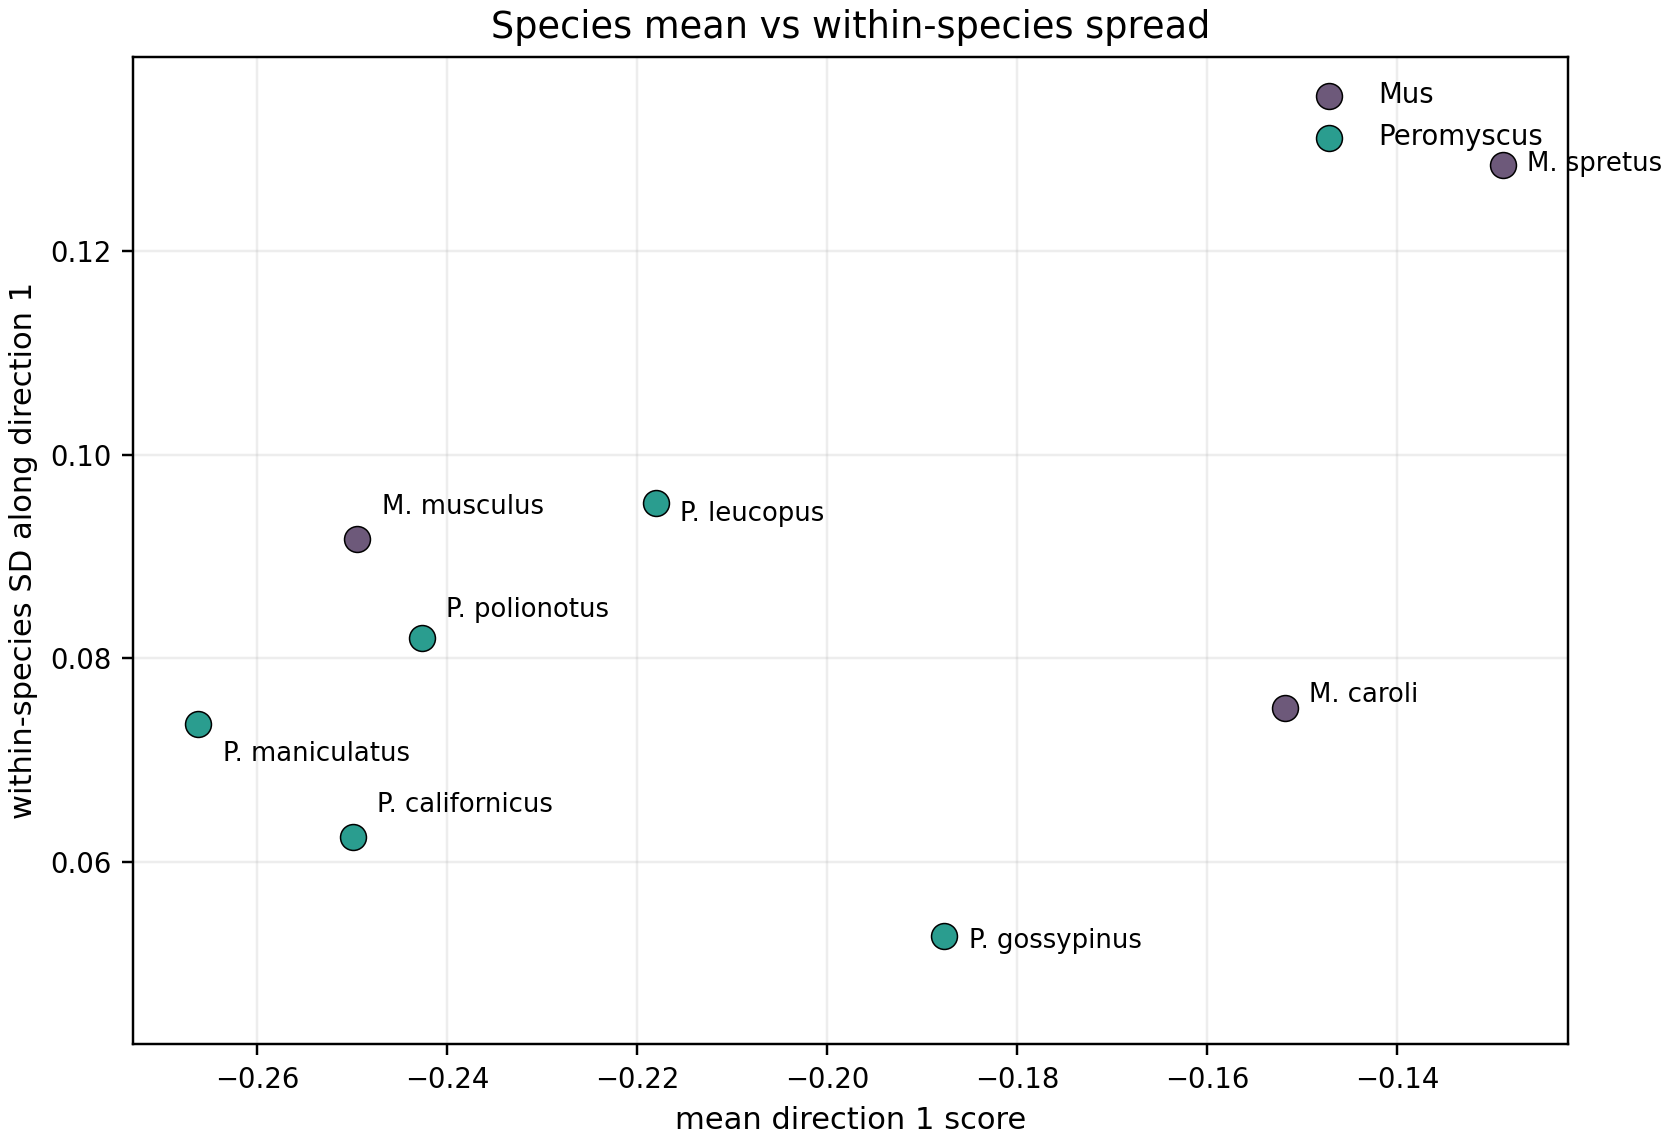

In [20]:
show_png(DIRECTION_DIR / 'setM_direction_1_species_mean_vs_within_spread.png', width=900)



## 11. Whitened Aligned-Chi Species Distances

This section checks whether species separation survives after normalizing out the pooled within-species covariance. These distances are Mahalanobis-like distances between species means in reference-aligned `chi` space.

How to read this:

- raw species-mean distance asks how far means are in ordinary aligned `chi` units
- whitened distance asks how many pooled within-species standard deviations apart those means are
- high-variance within-species directions are down-weighted
- the near-zero compositional direction is dropped before whitening
- clustering that survives whitening is less likely to be only a byproduct of high behavioral variability


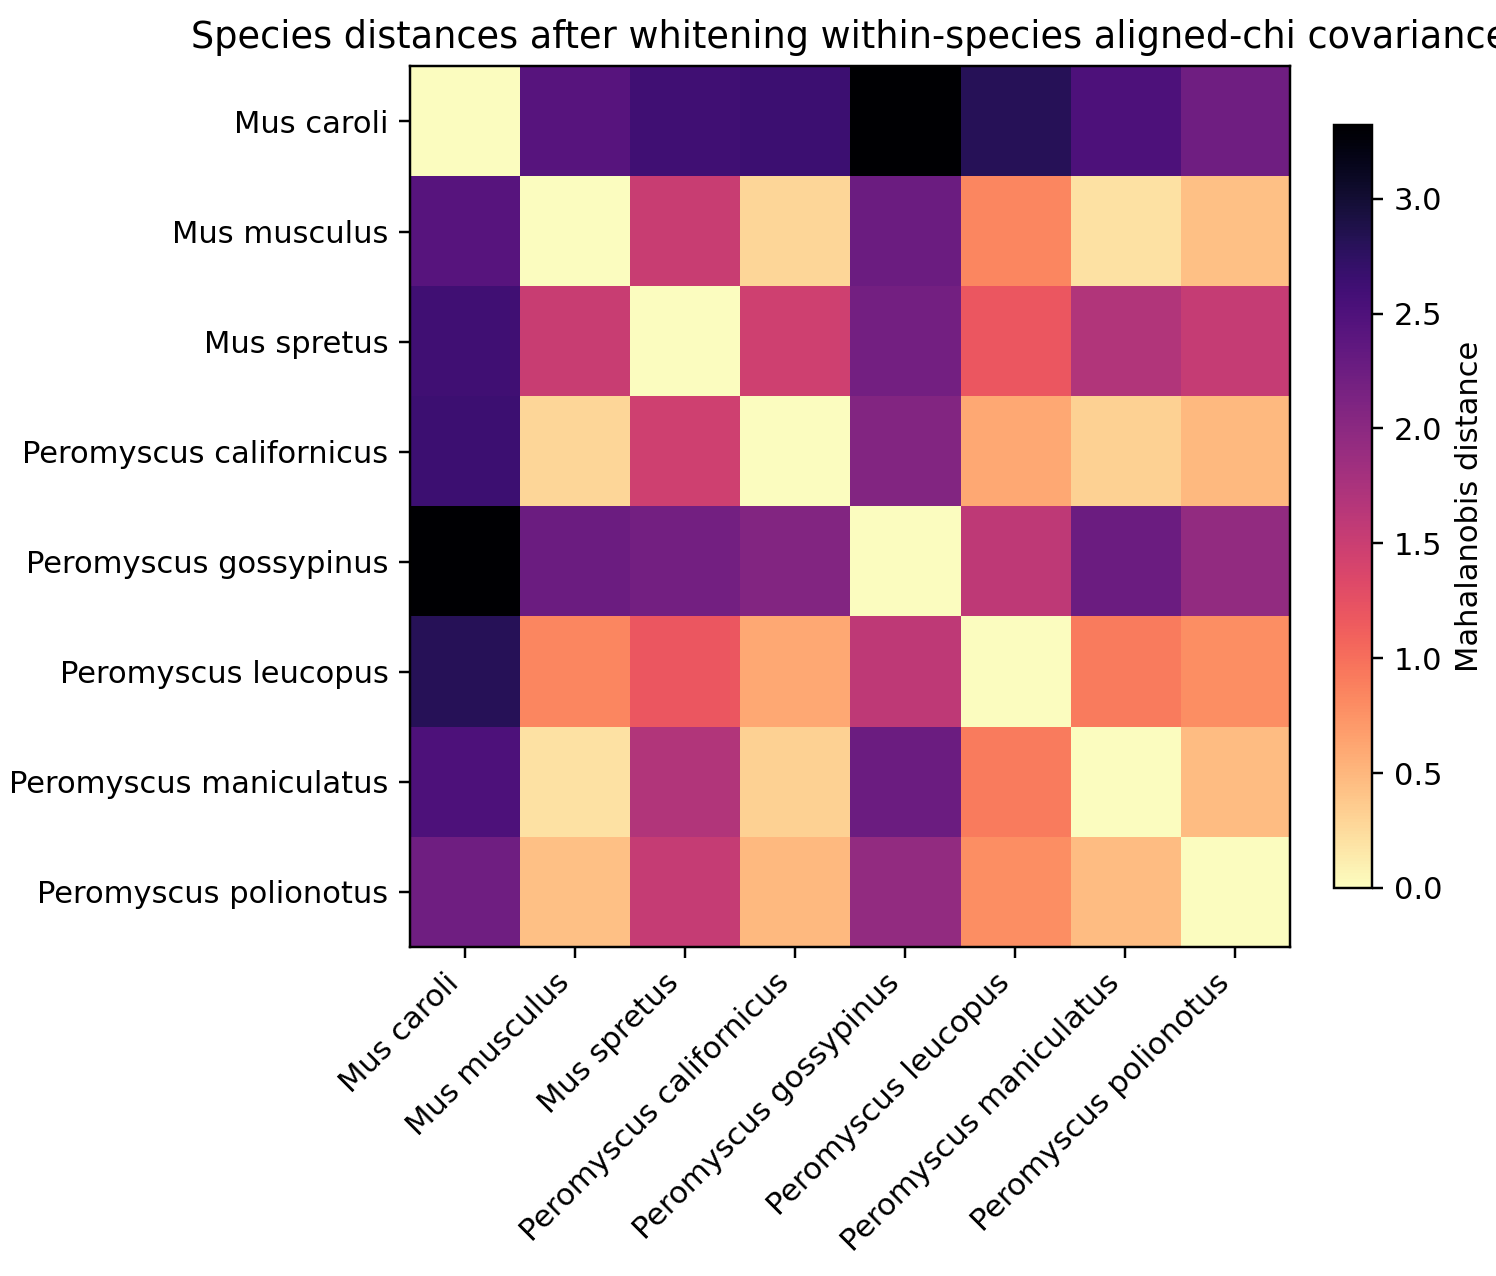

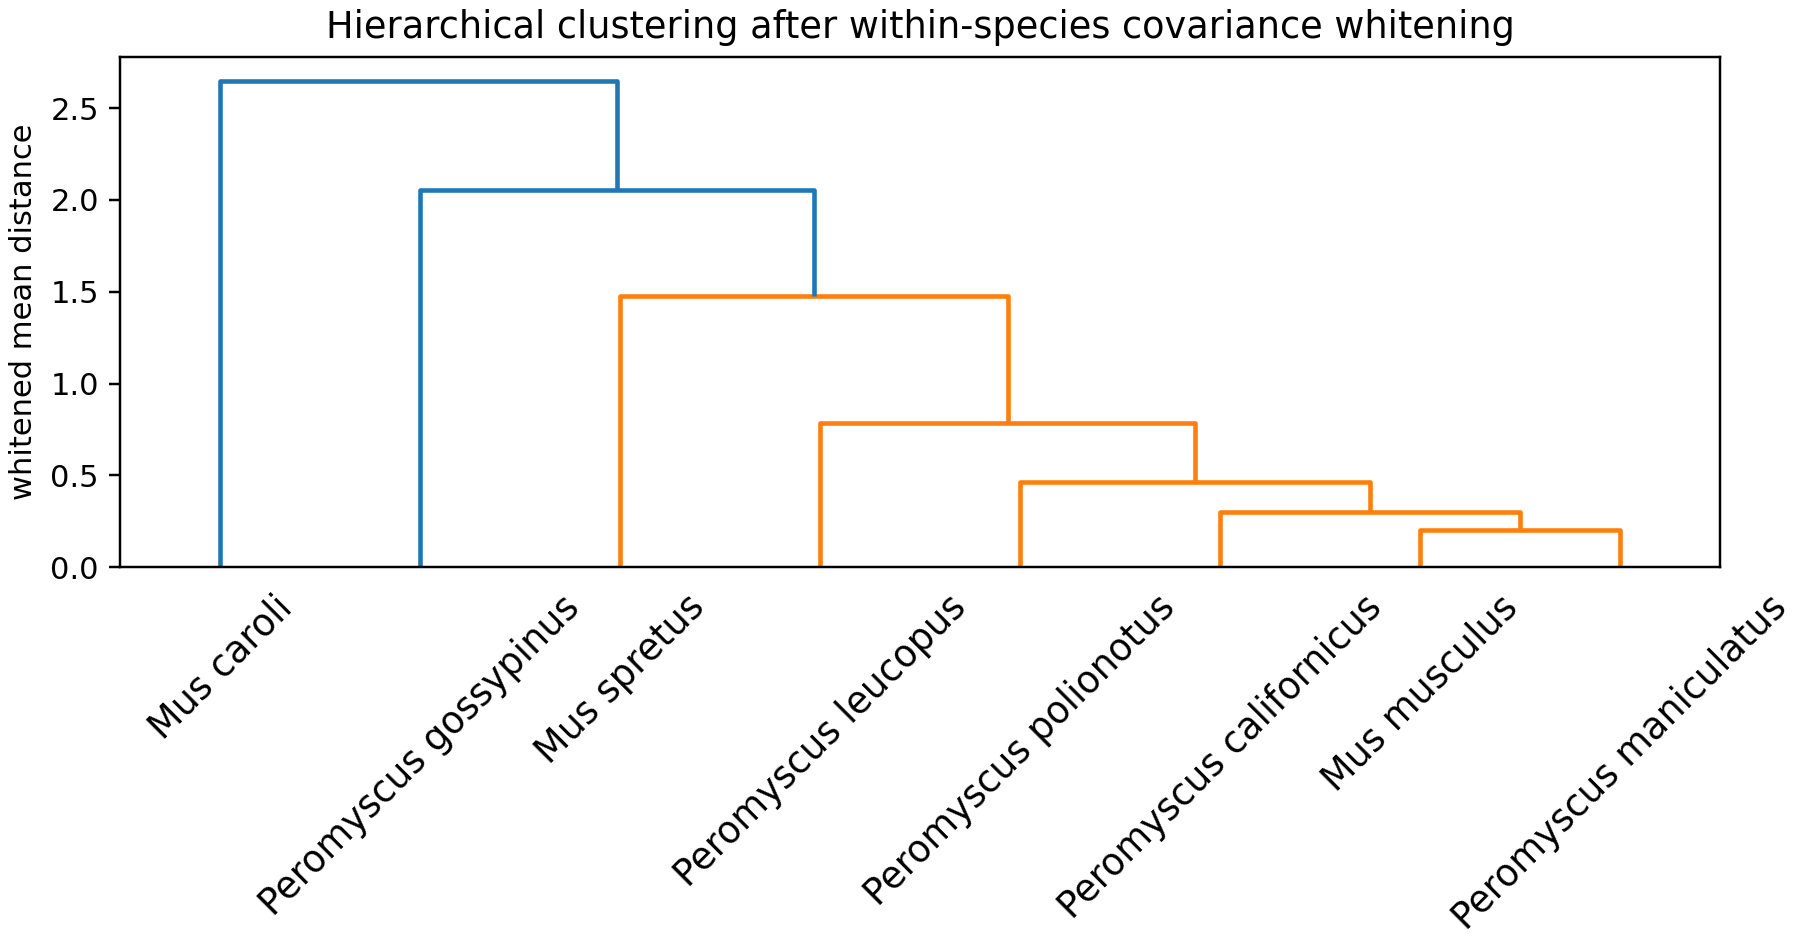

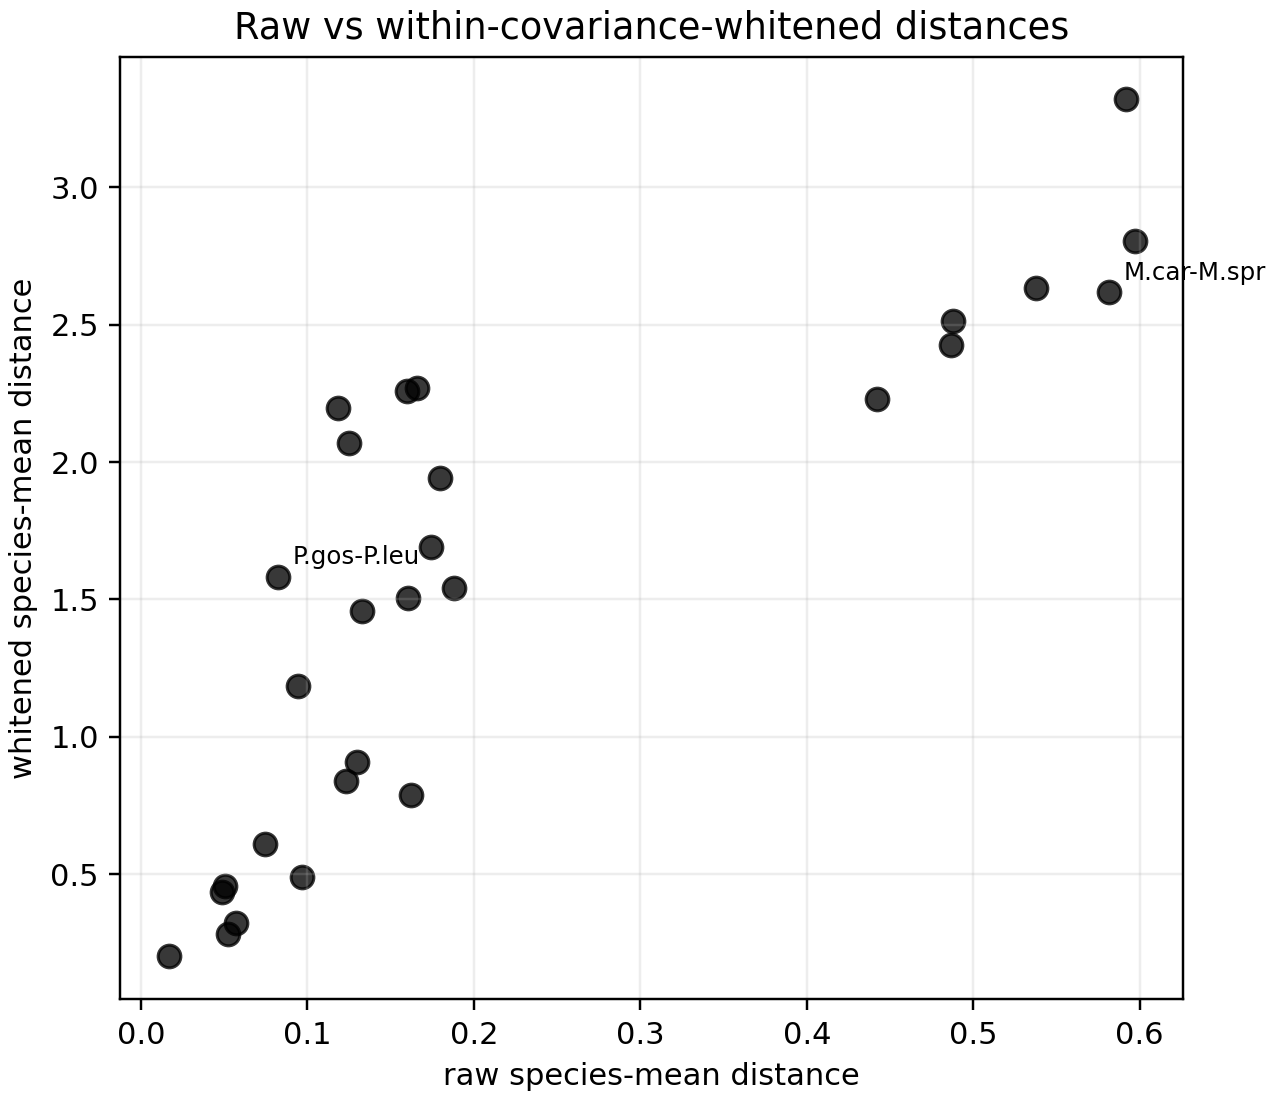

,direction,within_variance_eigenvalue,retained_for_whitening,within_sd,precision_weight_if_retained
0,1,4.986004e-02,True,0.223294,4.478408
1,2,7.258510e-03,True,0.085197,11.737518
2,3,2.400603e-03,True,0.048996,20.409851
3,4,-1.721172e-18,False,0.000000,NaN


,Mus_caroli,Mus_musculus,Mus_spretus,Peromyscus_californicus,Peromyscus_gossypinus,Peromyscus_leucopus,Peromyscus_maniculatus,Peromyscus_polionotus
Mus_caroli,0.000,2.427,2.618,2.633,3.319,2.804,2.512,2.229
Mus_musculus,2.427,0.000,1.507,0.283,2.259,0.841,0.201,0.436
Mus_spretus,2.618,1.507,0.000,1.460,2.198,1.185,1.692,1.541
Peromyscus_californicus,2.633,0.283,1.460,0.000,2.071,0.609,0.322,0.489
Peromyscus_gossypinus,3.319,2.259,2.198,2.071,0.000,1.583,2.268,1.940
Peromyscus_leucopus,2.804,0.841,1.185,0.609,1.583,0.000,0.910,0.788
Peromyscus_maniculatus,2.512,0.201,1.692,0.322,2.268,0.910,0.000,0.459
Peromyscus_polionotus,2.229,0.436,1.541,0.489,1.940,0.788,0.459,0.000


,species_a,species_b,raw_mean_euclidean_distance,whitened_mean_mahalanobis_distance,whitened_to_raw_ratio
11,Mus_musculus,Peromyscus_maniculatus,0.016629,0.201311,12.105706
8,Mus_musculus,Peromyscus_californicus,0.052395,0.282509,5.391852
20,Peromyscus_californicus,Peromyscus_maniculatus,0.056763,0.322150,5.675337
12,Mus_musculus,Peromyscus_polionotus,0.048377,0.436358,9.020016
27,Peromyscus_maniculatus,Peromyscus_polionotus,0.050387,0.458988,9.109258
21,Peromyscus_californicus,Peromyscus_polionotus,0.096677,0.489379,5.061990
19,Peromyscus_californicus,Peromyscus_leucopus,0.074228,0.608645,8.199712
26,Peromyscus_leucopus,Peromyscus_polionotus,0.162015,0.788433,4.866419
10,Mus_musculus,Peromyscus_leucopus,0.123317,0.840888,6.818925
25,Peromyscus_leucopus,Peromyscus_maniculatus,0.130032,0.910276,7.000383


In [21]:

WHITENED_DIR = OUT_DIR / 'whitened_aligned_chi_species_distances'

show_png(WHITENED_DIR / 'setM_whitened_aligned_chi_species_mean_distance_matrix.png', width=850)
show_png(WHITENED_DIR / 'setM_whitened_aligned_chi_species_mean_tree.png', width=950)
show_png(WHITENED_DIR / 'setM_raw_vs_whitened_aligned_chi_species_mean_distances.png', width=760)

whiten_eigen = pd.read_csv(WHITENED_DIR / 'setM_aligned_chi_whitening_eigenvalues.csv')
whiten_dist = pd.read_csv(WHITENED_DIR / 'setM_whitened_aligned_chi_species_mean_mahalanobis_distance.csv', index_col=0)
whiten_pairs = pd.read_csv(WHITENED_DIR / 'setM_raw_vs_whitened_species_mean_distance_pairs.csv')

display(whiten_eigen)
display(whiten_dist.round(3))
display(whiten_pairs.sort_values('whitened_mean_mahalanobis_distance').head(10))


## 12. Species Classifier From Chi Trajectories

The classifier asks whether short windows of aligned setM chi trajectories contain enough information to identify species. This is different from the enrichment-vector clustering: it uses time windows of chi trajectories rather than static basin syllable profiles.

How to read this:

- increasing accuracy with longer windows means species identity is more detectable when temporal context accumulates
- confusion matrix blocks reveal which species have similar chi dynamics
- high accuracy does not prove phylogenetic signal by itself; it proves species-discriminative structure in the aligned chi trajectories
- if classifier confusions match phylogenetic closeness, that supports a phylogenetic interpretation


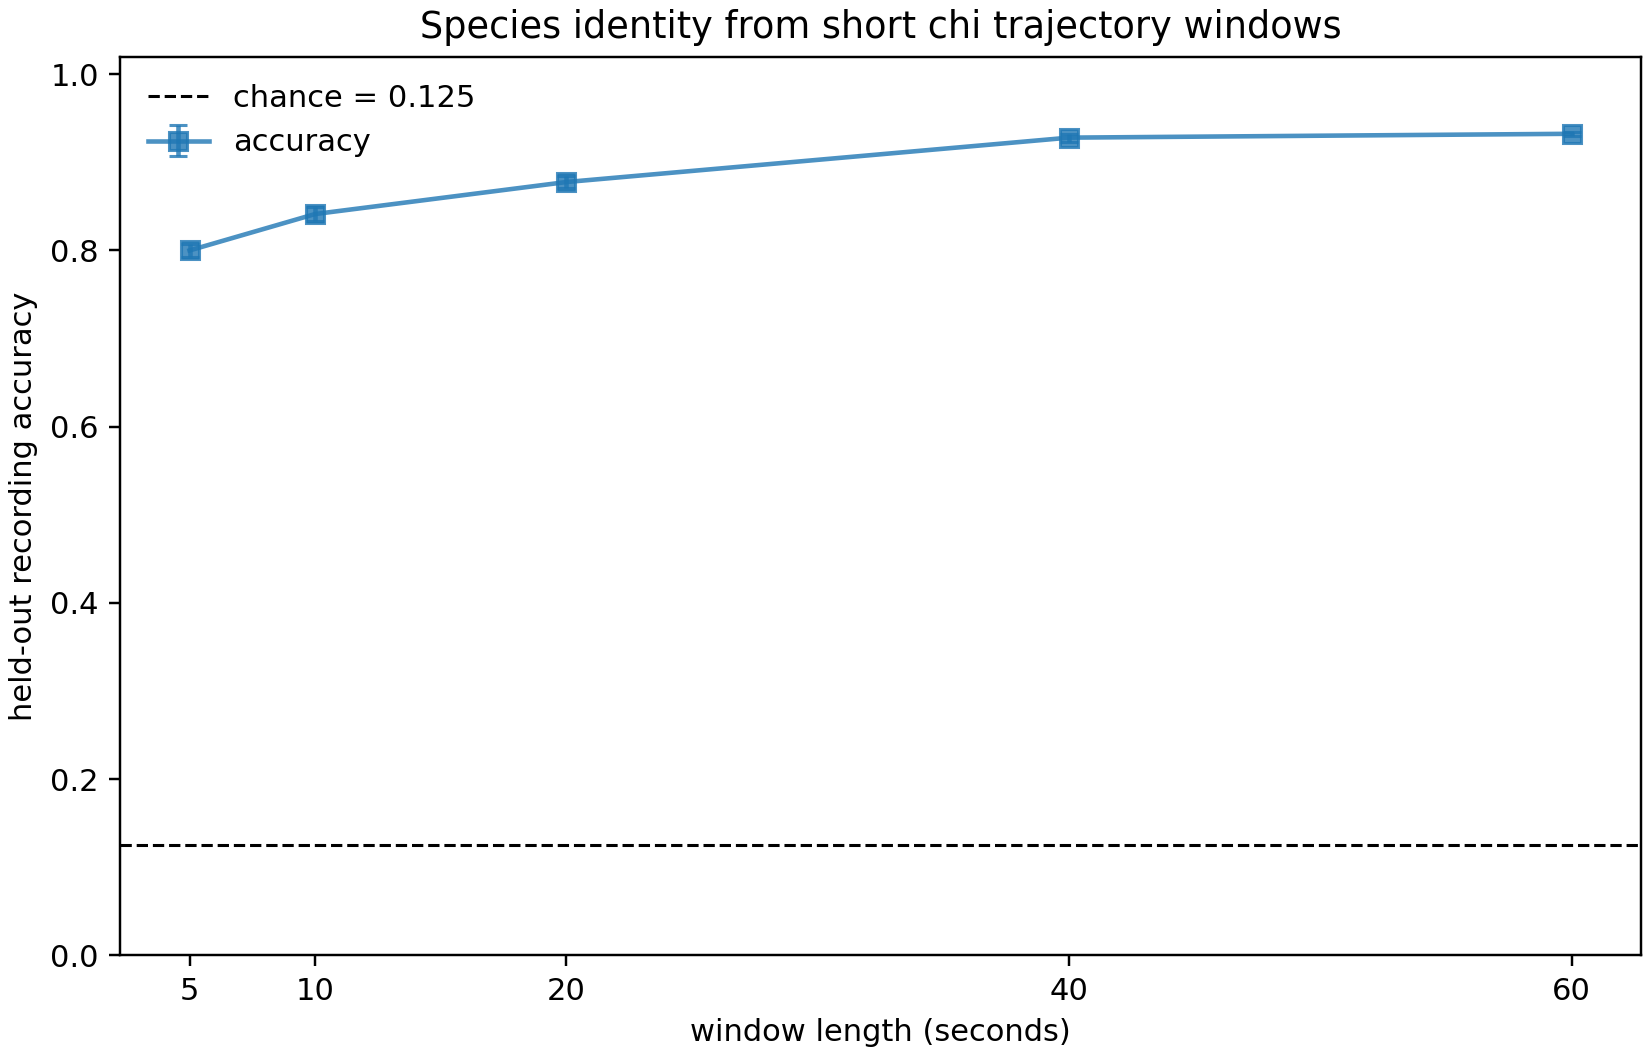

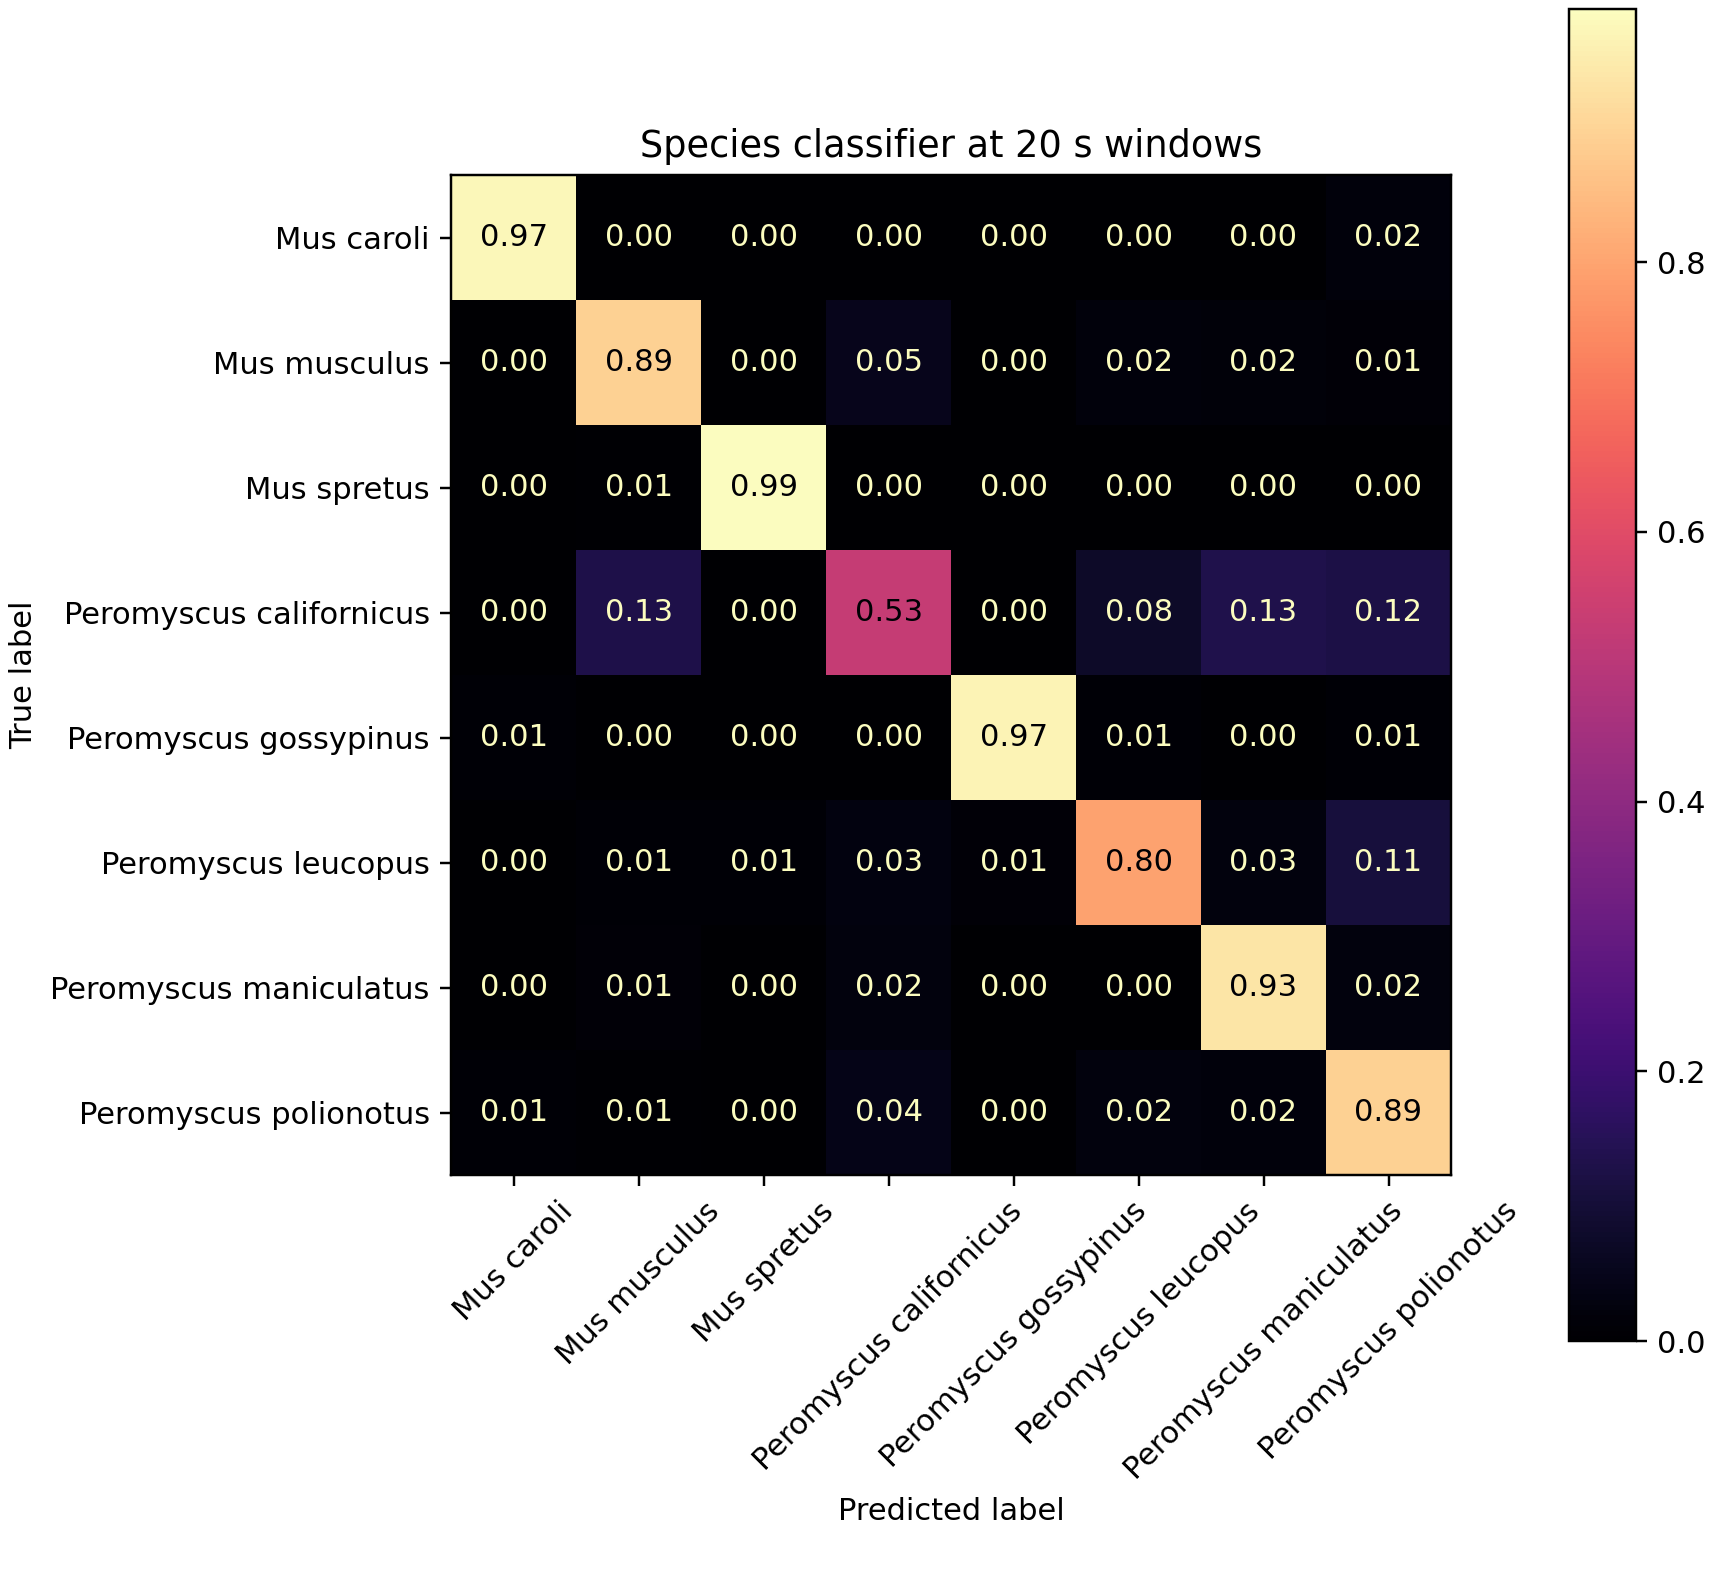

,window_seconds,mean_accuracy,sem_accuracy,mean_balanced_accuracy,sem_balanced_accuracy,n_splits,mean_test_windows
0,5.0,0.799860,0.007719,0.798673,0.008380,10,4019.6
1,10.0,0.841208,0.007547,0.838111,0.007789,10,4019.6
2,20.0,0.877543,0.006266,0.872123,0.006356,10,4019.6
3,40.0,0.927913,0.004417,0.923421,0.004919,10,4019.6
4,60.0,0.932282,0.002410,0.922676,0.002664,10,3695.6


In [15]:
show_png(CLASSIFIER_DIR / 'setM_species_chi_trajectory_window_accuracy.png', width=850)
show_png(CLASSIFIER_DIR / 'setM_species_20s_confusion_matrix_normalized.png', width=850)

accuracy = pd.read_csv(CLASSIFIER_DIR / 'setM_species_chi_trajectory_window_accuracy_summary.csv')
display(accuracy)


## 13. Suggested Reading Order For A Results Section

A clean story arc:

1. Define the basin-relative enrichment vector: four 50D arm vectors per species.
2. Show the matched enrichment distance matrix/dendrogram to ask whether basin-level behavior recovers species relationships.
3. Show heatmaps to demonstrate what behavioral features define the matched arms.
4. Use dot plots and genus contrasts to name the syllables driving differences.
5. Use fluctuation-divergence and Direction 1 plots to characterize the dominant aligned chi axis.
6. Use the species classifier as a complementary dynamic validation: species are separable from chi trajectories across time windows.

Best one-sentence caution: these representations are comparable because they are built from shared MoSeq syllable labels and matched setM basin enrichment profiles, but they remain behavioral phenotypes, not direct molecular phylogenies.
